
# 01. Regionalización hidroclimática de estaciones meteorológicas

**Tesis:** *Predicción de sequías mediante modelos de cópulas y datos hidrometeorológicos en la Región Sur del Perú*

## Propósito del cuaderno

Este notebook reproduce de forma íntegra la etapa de regionalización hidroclimática utilizada en la tesis. El flujo documentado es:

1. Lectura y control de la base climática mensual.
2. Reproducción de la **Tabla 6**.
3. Cálculo de la climatología mensual de precipitación.
4. Construcción de las **16 variables** utilizadas en el clustering:
   - 12 climatologías mensuales de precipitación;
   - altitud;
   - precipitación anual;
   - fracción DJFM;
   - coeficiente de variación mensual.
5. Estandarización mediante `scale()`.
6. Distancia euclidiana.
7. Agrupamiento jerárquico `Ward.D2`.
8. Evaluación diagnóstica mediante **Gap Statistic**.
9. Adopción de `k = 3` para la regionalización final.
10. Contraste independiente mediante **PAM**.
11. Alineación de etiquetas PAM–Ward antes de evaluar concordancia.
12. Generación de las Tablas 7, 8 y 9.
13. Generación de las Figuras 7, 8, 9, 10 y 11.
14. Exportación de todas las tablas, figuras e insumos de trazabilidad.
15. Registro del MD5 de la base y del entorno de R.

> **Criterio metodológico:** el Gap Statistic es un diagnóstico y no se fuerza para obtener `k = 3`. La clasificación oficial de la tesis es `Ward.D2, k = 3`; PAM se utiliza exclusivamente como contraste.

> **Variables auxiliares:** `ppt_mjjas`, `frac_mjjas` y `mes_pico` se calculan para descripción hidroclimática, pero **no forman parte de las 16 variables utilizadas en el clustering**.

### Ejecución recomendada

Abra este notebook desde el repositorio `Tesis_UNCP`, reinicie el kernel de R y ejecute **Run All** desde la primera hasta la última celda. Las tablas se mostrarán en el propio cuaderno y, simultáneamente, se guardarán en `03_resultados/01_regionalizacion/tablas`. Las figuras se mostrarán en el cuaderno y se guardarán en `03_resultados/01_regionalizacion/figuras`.


## Celda 1. Paquetes, opciones y rutas del proyecto

In [1]:

options(
  stringsAsFactors = FALSE,
  scipen = 999,
  width = 160
)

suppressPackageStartupMessages({
  library(here)
  library(tidyverse)
  library(lubridate)
  library(janitor)
  library(cluster)
  library(factoextra)
  library(maps)
  library(ggrepel)
  library(scales)
})

ruta_raiz <- here::here()

cat(
  "\n============================================================\n",
  "RAÍZ DEL PROYECTO\n",
  "============================================================\n",
  ruta_raiz,
  "\n",
  sep = ""
)

ruta_input <- here::here(
  "01_datos",
  "raw",
  "Base_Datos_Final_ETo_Pivot.csv"
)

ruta_intermedios <- here::here(
  "01_datos",
  "intermedios"
)

ruta_procesados <- here::here(
  "01_datos",
  "procesados"
)

ruta_tablas <- here::here(
  "03_resultados",
  "01_regionalizacion",
  "tablas"
)

ruta_figuras <- here::here(
  "03_resultados",
  "01_regionalizacion",
  "figuras"
)

ruta_reproducibilidad <- here::here(
  "04_documentacion",
  "reproducibilidad"
)

directorios <- c(
  ruta_intermedios,
  ruta_procesados,
  ruta_tablas,
  ruta_figuras,
  ruta_reproducibilidad
)

for (d in directorios) {
  dir.create(
    d,
    recursive = TRUE,
    showWarnings = FALSE
  )
}

if (!file.exists(ruta_input)) {
  stop(
    "ERROR: no se encontró la base de entrada:\n",
    ruta_input,
    "\n\nAbra el notebook desde la raíz del repositorio."
  )
}

cat("\nBase de entrada:\n", ruta_input, "\n")
cat("\nCarpeta de tablas:\n", ruta_tablas, "\n")
cat("\nCarpeta de figuras:\n", ruta_figuras, "\n")


Warning message:
"package 'here' was built under R version 4.5.3"
Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
Warning message:
"package 'janitor' was built under R version 4.5.3"
Warning message:
"package 'cluster' was built under R version 4.5.3"
Warning message:
"package 'factoextra' was built under R version 4.5.3"
Warning message:
"package 'maps' was built under R version 4.5.3"
Warning message:
"package 'ggrepel' was built under R version 4.5.3"



RAÍZ DEL PROYECTO
h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB

Base de entrada:
 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/raw/Base_Datos_Final_ETo_Pivot.csv 

Carpeta de tablas:
 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas 

Carpeta de figuras:
 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/figuras 



## Celda 2. Lectura y control de la base original

La base se lee sin modificar los datos originales. Después de `janitor::clean_names()` se imprimen los nombres internos de las columnas. En particular:

- `ETo_dia` pasa a `e_to_dia`;
- `ETo_mensual` pasa a `e_to_mensual`.

Esto deja documentada la correspondencia entre los nombres originales del CSV y los nombres utilizados por R.


In [2]:

df <- read.csv(
  ruta_input,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  janitor::clean_names()

cat("\nNombres de columnas después de clean_names():\n")
print(names(df))

df <- df %>%
  mutate(
    fecha = as.Date(fecha),
    anio = lubridate::year(fecha),
    mes = lubridate::month(fecha),
    estacion = stringr::str_squish(
      stringr::str_to_upper(estacion)
    )
  )

variables_requeridas <- c(
  "fecha",
  "estacion",
  "latitud",
  "longitud",
  "altitud",
  "hr101",
  "pt101",
  "tm101",
  "vtmed",
  "e_to_dia",
  "dias_en_mes",
  "e_to_mensual"
)

faltantes <- setdiff(
  variables_requeridas,
  names(df)
)

if (length(faltantes) > 0) {
  stop(
    "ERROR. Faltan variables requeridas: ",
    paste(faltantes, collapse = ", ")
  )
}

duplicados <- df %>%
  count(
    estacion,
    fecha,
    name = "n"
  ) %>%
  filter(n > 1)

if (nrow(duplicados) > 0) {
  print(duplicados)
  stop("ERROR: existen registros duplicados estación-fecha.")
}

n_registros <- nrow(df)
n_estaciones <- n_distinct(df$estacion)
fecha_inicio <- min(df$fecha, na.rm = TRUE)
fecha_fin <- max(df$fecha, na.rm = TRUE)

md5_base <- unname(
  tools::md5sum(ruta_input)
)

cat(
  "\n============================================================\n",
  "CONTROL DE LA BASE\n",
  "============================================================\n",
  "Registros mensuales : ", n_registros, "\n",
  "Estaciones          : ", n_estaciones, "\n",
  "Fecha inicial       : ", as.character(fecha_inicio), "\n",
  "Fecha final         : ", as.character(fecha_fin), "\n",
  "MD5 de la base      : ", md5_base, "\n",
  sep = ""
)



Nombres de columnas después de clean_names():
 [1] "fecha"        "estacion"     "latitud"      "longitud"     "altitud"      "hr101"        "pt101"        "tm101"        "vtmed"        "e_to_dia"    
[11] "dias_en_mes"  "e_to_mensual"

CONTROL DE LA BASE
Registros mensuales : 18144
Estaciones          : 28
Fecha inicial       : 1970-01-01
Fecha final         : 2023-12-01
MD5 de la base      : 7235b7dc7b685f99cfb62ede8d744cf5



## Celda 3. Control de metadatos de las estaciones

Cada estación debe presentar una única latitud, longitud y altitud. Si se encuentra más de un valor para alguna estación, la ejecución se detiene.

Se muestra también el valor de altitud utilizado para **PUCARA**, sin modificarlo dentro del código.


In [5]:
# ======================================================================
# CELDA 3. CONTROL DE METADATOS DE LAS 28 ESTACIONES
# ======================================================================

# ----------------------------------------------------------------------
# Cada estación debe tener una sola latitud, longitud y altitud.
# Si una estación presenta más de un valor para cualquiera de estos
# metadatos, la ejecución se detiene porque la regionalización requiere
# una localización espacial única por estación.
# ----------------------------------------------------------------------

control_metadata <- df %>%
  group_by(estacion) %>%
  summarise(
    n_latitud = n_distinct(latitud),
    n_longitud = n_distinct(longitud),
    n_altitud = n_distinct(altitud),
    .groups = "drop"
  )


# ----------------------------------------------------------------------
# Identificar posibles inconsistencias en los metadatos espaciales.
# ----------------------------------------------------------------------

problemas_metadata <- control_metadata %>%
  filter(
    n_latitud != 1 |
    n_longitud != 1 |
    n_altitud != 1
  )


if (nrow(problemas_metadata) > 0) {

  cat(
    "\nATENCIÓN: se detectaron estaciones con metadatos inconsistentes:\n"
  )

  print(
    problemas_metadata,
    n = Inf,
    width = Inf
  )

  stop(
    "ERROR: existen estaciones con más de una latitud, longitud o altitud."
  )
}


cat(
  "\nControl de metadatos espaciales: OK\n"
)

cat(
  "Las ",
  nrow(control_metadata),
  " estaciones presentan una única latitud, longitud y altitud.\n",
  sep = ""
)


# ----------------------------------------------------------------------
# Construcción de la tabla de metadatos por estación.
#
# Se utiliza el primer valor porque previamente se verificó que cada
# estación posee una única latitud, longitud y altitud.
# ----------------------------------------------------------------------

resumen_estaciones <- df %>%
  group_by(estacion) %>%
  summarise(
    latitud = first(latitud),
    longitud = first(longitud),
    altitud = first(altitud),
    n_registros = n(),

    ppt_media_mensual = mean(
      pt101,
      na.rm = TRUE
    ),

    eto_media_mensual = mean(
      e_to_mensual,
      na.rm = TRUE
    ),

    .groups = "drop"
  ) %>%
  arrange(estacion)


# ----------------------------------------------------------------------
# Guardar la tabla completa de metadatos.
# ----------------------------------------------------------------------

readr::write_csv(
  resumen_estaciones,
  file.path(
    ruta_tablas,
    "resumen_estaciones_base.csv"
  )
)


# ----------------------------------------------------------------------
# Mostrar la tabla dentro del notebook.
# ----------------------------------------------------------------------

cat(
  "\n============================================================\n",
  "METADATOS DE LAS ESTACIONES\n",
  "============================================================\n"
)

print(
  resumen_estaciones,
  n = Inf,
  width = Inf
)


# ----------------------------------------------------------------------
# CONTROL ESPECÍFICO DE LA ESTACIÓN PUCARA / PUCARÁ
#
# En versiones preliminares de la base se detectó una altitud incorrecta
# para esta estación. Por ello se registra explícitamente el valor que
# entra en esta ejecución.
#
# IMPORTANTE:
# El código NO modifica la altitud.
# Únicamente consulta y documenta el valor existente en la base original.
#
# iconv(..., "ASCII//TRANSLIT") permite comparar nombres con o sin tilde,
# por ejemplo PUCARÁ y PUCARA, sin requerir paquetes adicionales.
# ----------------------------------------------------------------------

estacion_ascii <- iconv(
  resumen_estaciones$estacion,
  from = "",
  to = "ASCII//TRANSLIT"
)

estacion_ascii <- toupper(
  trimws(estacion_ascii)
)


pucara_idx <- which(
  estacion_ascii == "PUCARA"
)


if (length(pucara_idx) == 1) {

  altitud_pucara <- resumen_estaciones$altitud[
    pucara_idx
  ]

  nombre_pucara <- resumen_estaciones$estacion[
    pucara_idx
  ]

  cat(
    "\n============================================================\n",
    "CONTROL ESPECÍFICO DE PUCARA\n",
    "============================================================\n",
    "Nombre registrado : ",
    nombre_pucara,
    "\n",
    "Altitud utilizada : ",
    altitud_pucara,
    " m s.n.m.\n",
    sep = ""
  )

} else if (length(pucara_idx) == 0) {

  altitud_pucara <- NA_real_

  warning(
    "No se encontró la estación PUCARA/PUCARÁ en la base."
  )

} else {

  altitud_pucara <- NA_real_

  warning(
    "Se encontraron múltiples coincidencias para PUCARA/PUCARÁ. ",
    "Revisar los nombres de estación."
  )
}


# ----------------------------------------------------------------------
# Control adicional del número de estaciones.
#
# La tesis utiliza 28 estaciones meteorológicas.
# Este control no modifica los datos; únicamente advierte si una nueva
# ejecución presenta una cantidad diferente.
# ----------------------------------------------------------------------

if (nrow(resumen_estaciones) != 28) {

  warning(
    "ATENCIÓN: la base contiene ",
    nrow(resumen_estaciones),
    " estaciones y la tesis documenta 28."
  )

} else {

  cat(
    "\nNúmero de estaciones verificado: 28\n"
  )
}


Control de metadatos espaciales: OK
Las 28 estaciones presentan una única latitud, longitud y altitud.

 METADATOS DE LAS ESTACIONES
# A tibble: 28 × 7
   estacion           latitud longitud altitud n_registros ppt_media_mensual eto_media_mensual
   <chr>                <dbl>    <dbl>   <dbl>       <int>             <dbl>             <dbl>
 1 ANANEA               -14.7    -69.5    4660         648            52.6                75.8
 2 ANDAHUAYLAS          -13.6    -73.4    2865         648            54.1                95.3
 3 ANTA ANCACHURO       -13.5    -72.2    3324         648            65.2                97.4
 4 AYMARAES             -14.3    -73.3    2964         648            58.4               106. 
 5 CANDARAVE            -17.3    -70.3    3435         648            15.8                95.7
 6 CARAVELI             -15.8    -73.4    1755         648             2.98              131. 
 7 CAYLLOMA             -15.2    -71.8    4327         648            61.1             


## Celda 4. Tabla 6 — resumen global de la base climática

Se calculan mínimo, Q1, mediana, media, Q3 y máximo. La tabla aparece en el notebook y se exporta con precisión completa.


In [6]:

estadisticos_6 <- function(x) {
  c(
    minimo = min(x, na.rm = TRUE),
    q1 = unname(
      quantile(
        x,
        probs = 0.25,
        na.rm = TRUE,
        type = 7
      )
    ),
    mediana = median(x, na.rm = TRUE),
    media = mean(x, na.rm = TRUE),
    q3 = unname(
      quantile(
        x,
        probs = 0.75,
        na.rm = TRUE,
        type = 7
      )
    ),
    maximo = max(x, na.rm = TRUE)
  )
}

dic_tabla_06 <- tibble(
  campo = c(
    "latitud",
    "longitud",
    "altitud",
    "hr101",
    "pt101",
    "tm101",
    "vtmed",
    "e_to_dia",
    "e_to_mensual",
    "anio",
    "mes"
  ),
  variable = c(
    "Latitud (°)",
    "Longitud (°)",
    "Altitud (m s.n.m.)",
    "Humedad relativa (%)",
    "Precipitación mensual (mm)",
    "Temperatura media (°C)",
    "Velocidad del viento (m s-1)",
    "ETo diaria (mm d-1)",
    "ETo mensual (mm)",
    "Año",
    "Mes"
  )
)

tabla_06_resumen_global <- purrr::map_dfr(
  seq_len(nrow(dic_tabla_06)),
  function(i) {
    campo_i <- dic_tabla_06$campo[i]
    stats_i <- estadisticos_6(df[[campo_i]])

    tibble(
      variable = dic_tabla_06$variable[i],
      minimo = stats_i["minimo"],
      q1 = stats_i["q1"],
      mediana = stats_i["mediana"],
      media = stats_i["media"],
      q3 = stats_i["q3"],
      maximo = stats_i["maximo"]
    )
  }
)

readr::write_csv(
  tabla_06_resumen_global,
  file.path(
    ruta_tablas,
    "tabla_06_resumen_global_base.csv"
  )
)

tabla_06_mostrar <- tabla_06_resumen_global %>%
  mutate(
    across(
      where(is.numeric),
      ~ round(.x, 2)
    )
  )

cat(
  "\n============================================================\n",
  "TABLA 6. RESUMEN GLOBAL DE LA BASE CLIMÁTICA\n",
  "============================================================\n"
)

print(
  tabla_06_mostrar,
  n = Inf,
  width = Inf
)



 TABLA 6. RESUMEN GLOBAL DE LA BASE CLIMÁTICA
# A tibble: 11 × 7
   variable                      minimo      q1 mediana   media      q3  maximo
   <chr>                          <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 Latitud (°)                   -18.2   -15.9   -15.0   -15.2   -14.1   -13.5 
 2 Longitud (°)                  -73.8   -72.9   -71.8   -71.7   -70.5   -69.4 
 3 Altitud (m s.n.m.)             25    2842.   3314.   2978.   3880.   4660   
 4 Humedad relativa (%)           21.7    62.3    73.3    70.7    80.6   100   
 5 Precipitación mensual (mm)      0       0.3    14      44.7    71     424.  
 6 Temperatura media (°C)         -1.41    9.55   12.3    12.4    15.2    26.4 
 7 Velocidad del viento (m s-1)    0       1.8     2.6     2.79    3.5    27.8 
 8 ETo diaria (mm d-1)             1.42    2.69    3.26    3.27    3.81    7.04
 9 ETo mensual (mm)               42.5    82.1    98.6    99.4   116.    211.  
10 Año                          1970    1983    1996. 


## Celda 5. Climatología mensual de precipitación

Se calcula la precipitación media de cada mes calendario para cada estación durante 1970–2023. Esta tabla constituye el insumo de la Figura 7 y de las doce variables mensuales del clustering.


In [7]:

clim_mensual <- df %>%
  group_by(
    estacion,
    latitud,
    longitud,
    altitud,
    mes
  ) %>%
  summarise(
    ppt_media_mensual = mean(
      pt101,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    estacion,
    mes
  )

readr::write_csv(
  clim_mensual,
  file.path(
    ruta_tablas,
    "fig07_climatologia.csv"
  )
)

cat("\nCLIMATOLOGÍA MENSUAL - primeras 24 filas:\n")
print(
  clim_mensual %>% slice_head(n = 24),
  n = 24,
  width = Inf
)



CLIMATOLOGÍA MENSUAL - primeras 24 filas:
# A tibble: 24 × 6
   estacion    latitud longitud altitud   mes ppt_media_mensual
   <chr>         <dbl>    <dbl>   <dbl> <dbl>             <dbl>
 1 ANANEA        -14.7    -69.5    4660     1            123.  
 2 ANANEA        -14.7    -69.5    4660     2            103.  
 3 ANANEA        -14.7    -69.5    4660     3             94.7 
 4 ANANEA        -14.7    -69.5    4660     4             45.0 
 5 ANANEA        -14.7    -69.5    4660     5             14.9 
 6 ANANEA        -14.7    -69.5    4660     6              9.29
 7 ANANEA        -14.7    -69.5    4660     7              8.96
 8 ANANEA        -14.7    -69.5    4660     8             13.5 
 9 ANANEA        -14.7    -69.5    4660     9             23.6 
10 ANANEA        -14.7    -69.5    4660    10             43.5 
11 ANANEA        -14.7    -69.5    4660    11             58.3 
12 ANANEA        -14.7    -69.5    4660    12             92.4 
13 ANDAHUAYLAS   -13.6    -73.4    2865   

## Celda 6. Figura 7 — climatología mensual de precipitación por estación

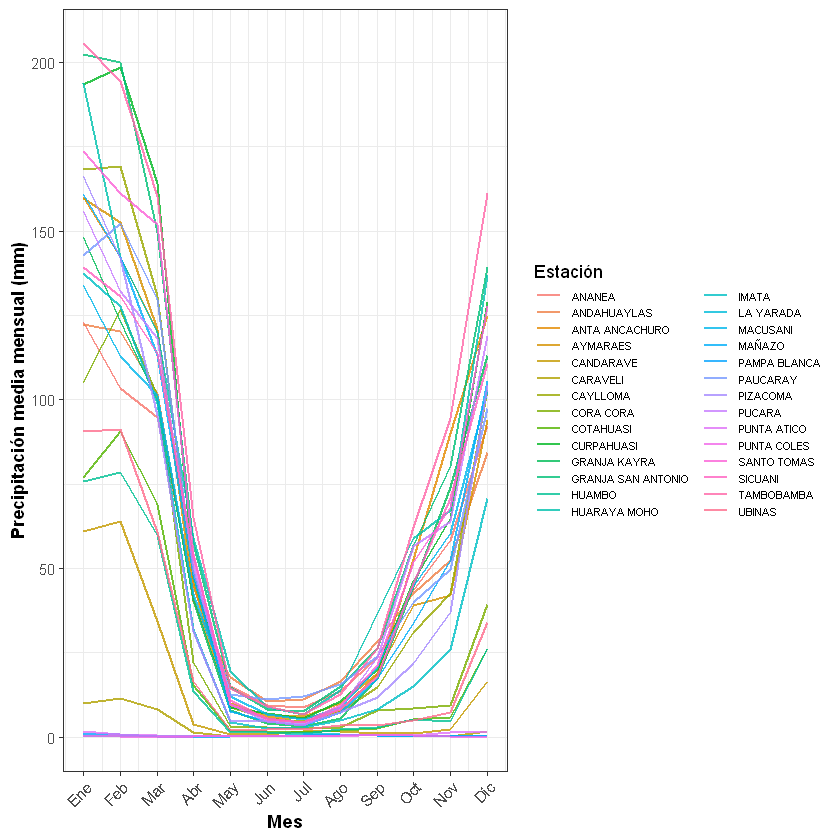

In [8]:

meses_etiqueta <- c(
  "Ene", "Feb", "Mar", "Abr",
  "May", "Jun", "Jul", "Ago",
  "Sep", "Oct", "Nov", "Dic"
)

p_climatologia <- ggplot(
  clim_mensual,
  aes(
    x = mes,
    y = ppt_media_mensual,
    group = estacion,
    colour = estacion
  )
) +
  geom_line(
    linewidth = 0.65,
    alpha = 0.80
  ) +
  scale_x_continuous(
    breaks = 1:12,
    labels = meses_etiqueta
  ) +
  labs(
    x = "Mes",
    y = "Precipitación media mensual (mm)",
    colour = "Estación"
  ) +
  theme_bw(base_size = 11) +
  theme(
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    ),
    legend.position = "right",
    legend.text = element_text(size = 6.5),
    legend.key.height = grid::unit(
      0.35,
      "cm"
    )
  )

print(p_climatologia)

ggsave(
  filename = file.path(
    ruta_figuras,
    "climatologia_mensual_estaciones.png"
  ),
  plot = p_climatologia,
  width = 9.0,
  height = 6.5,
  dpi = 600,
  bg = "white"
)

ggsave(
  filename = file.path(
    ruta_figuras,
    "climatologia_mensual_estaciones.pdf"
  ),
  plot = p_climatologia,
  width = 9.0,
  height = 6.5,
  device = grDevices::cairo_pdf,
  bg = "white"
)



## Celda 7. Construcción de la base de regionalización

Se generan las doce climatologías `p_01 ... p_12` y los indicadores hidroclimáticos.

**Importante:** `ppt_mjjas`, `frac_mjjas` y `mes_pico` son descriptores auxiliares. Se conservan para trazabilidad y descripción, pero no forman parte de las 16 variables utilizadas para Ward.D2.


In [10]:

clim_wide <- clim_mensual %>%
  mutate(
    mes_lab = sprintf(
      "p_%02d",
      mes
    )
  ) %>%
  select(
    estacion,
    latitud,
    longitud,
    altitud,
    mes_lab,
    ppt_media_mensual
  ) %>%
  pivot_wider(
    names_from = mes_lab,
    values_from = ppt_media_mensual
  )

indices <- clim_mensual %>%
  group_by(estacion) %>%
  summarise(
    ppt_anual = sum(
      ppt_media_mensual,
      na.rm = TRUE
    ),
    ppt_djfm = sum(
      ppt_media_mensual[
        mes %in% c(12, 1, 2, 3)
      ],
      na.rm = TRUE
    ),
    ppt_mjjas = sum(
      ppt_media_mensual[
        mes %in% c(5, 6, 7, 8, 9)
      ],
      na.rm = TRUE
    ),
    cv_mensual =
      sd(
        ppt_media_mensual,
        na.rm = TRUE
      ) /
      mean(
        ppt_media_mensual,
        na.rm = TRUE
      ),
    mes_pico = mes[
      which.max(
        ppt_media_mensual
      )
    ][1],
    .groups = "drop"
  ) %>%
  mutate(
    frac_djfm = if_else(
      ppt_anual > 0,
      ppt_djfm / ppt_anual,
      NA_real_
    ),
    frac_mjjas = if_else(
      ppt_anual > 0,
      ppt_mjjas / ppt_anual,
      NA_real_
    )
  )

base_cluster <- clim_wide %>%
  left_join(
    indices,
    by = "estacion"
  ) %>%
  arrange(estacion)

cat("\nBASE A NIVEL DE ESTACIÓN:\n")
print(
  base_cluster,
  n = Inf,
  width = Inf
)



BASE A NIVEL DE ESTACIÓN:
# A tibble: 28 × 23
   estacion           latitud longitud altitud    p_01    p_02     p_03    p_04   p_05   p_06   p_07   p_08   p_09   p_10   p_11     p_12 ppt_anual ppt_djfm
   <chr>                <dbl>    <dbl>   <dbl>   <dbl>   <dbl>    <dbl>   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>    <dbl>     <dbl>    <dbl>
 1 ANANEA               -14.7    -69.5    4660 123.    103.     94.7    45.0    14.9    9.29   8.96  13.5   23.6   43.5   58.3    92.4       631.    413.   
 2 ANDAHUAYLAS          -13.6    -73.4    2865 122.    120.    102.     40.2    17.6   10.6   11.3   16.6   28.4   42.6   52.3    84.5       649.    429.   
 3 ANTA ANCACHURO       -13.5    -72.2    3324 160.    142.    120.     45.4     9.29   5.80   5.50   7.81  18.5   52.6   90.1   125.        782.    547.   
 4 AYMARAES             -14.3    -73.3    2964 160.    152.    121.     41.1    10.1    6.35   6.11  10.2   19.0   39.0   42.1    93.8       701.    527.   
 5 CANDARAV


## Celda 8. Definición explícita de las 16 variables del clustering

El vector final contiene exactamente:

- `p_01 ... p_12`;
- `altitud`;
- `ppt_anual`;
- `frac_djfm`;
- `cv_mensual`.

La ejecución se detiene si falta alguna variable, si aparecen `NA` o si existe algún valor no finito.


In [13]:

variables_cluster <- c(
  sprintf(
    "p_%02d",
    1:12
  ),
  "altitud",
  "ppt_anual",
  "frac_djfm",
  "cv_mensual"
)

if (length(variables_cluster) != 16) {
  stop(
    "ERROR: el vector de regionalización no contiene 16 variables."
  )
}

faltantes_cluster <- setdiff(
  variables_cluster,
  names(base_cluster)
)

if (length(faltantes_cluster) > 0) {
  stop(
    "ERROR. Faltan variables del clustering: ",
    paste(
      faltantes_cluster,
      collapse = ", "
    )
  )
}

vars_cluster <- base_cluster %>%
  select(
    all_of(
      variables_cluster
    )
  )

if (anyNA(vars_cluster)) {
  stop(
    "ERROR: existen NA en las 16 variables del clustering."
  )
}

if (
  any(
    !is.finite(
      as.matrix(vars_cluster)
    )
  )
) {
  stop(
    "ERROR: existen valores no finitos en las variables del clustering."
  )
}

cat(
  "\n============================================================\n",
  "VARIABLES UTILIZADAS EN EL CLUSTERING\n",
  "============================================================\n"
)

print(
  tibble(
    numero = 1:16,
    variable = variables_cluster
  ),
  n = 16
)



 VARIABLES UTILIZADAS EN EL CLUSTERING
# A tibble: 16 × 2
   numero variable  
    <int> <chr>     
 1      1 p_01      
 2      2 p_02      
 3      3 p_03      
 4      4 p_04      
 5      5 p_05      
 6      6 p_06      
 7      7 p_07      
 8      8 p_08      
 9      9 p_09      
10     10 p_10      
11     11 p_11      
12     12 p_12      
13     13 altitud   
14     14 ppt_anual 
15     15 frac_djfm 
16     16 cv_mensual


## Celda 9. Estandarización de las 16 variables

In [18]:
# ======================================================================
# CELDA 9. ESTANDARIZACIÓN DE LAS 16 VARIABLES
# ======================================================================

# ----------------------------------------------------------------------
# Las 16 variables utilizadas en la regionalización poseen escalas y
# unidades diferentes. Por esta razón, antes de calcular las distancias
# euclidianas se estandarizan mediante:
#
#                  x - media
#          z = ----------------
#              desviación estándar
#
# De esta manera, cada variable queda expresada en una escala comparable
# con media aproximadamente 0 y desviación estándar aproximadamente 1.
# ----------------------------------------------------------------------


# ----------------------------------------------------------------------
# 1. Verificar nuevamente las dimensiones de la matriz
# ----------------------------------------------------------------------

cat(
  "\n============================================================\n",
  "ESTANDARIZACIÓN DE LAS 16 VARIABLES\n",
  "============================================================\n"
)

cat(
  "Número de estaciones : ",
  nrow(vars_cluster),
  "\n",
  sep = ""
)

cat(
  "Número de variables  : ",
  ncol(vars_cluster),
  "\n",
  sep = ""
)


if (ncol(vars_cluster) != 16) {

  stop(
    "ERROR: se esperaban 16 variables para la regionalización, pero se encontraron ",
    ncol(vars_cluster),
    "."
  )
}


# ----------------------------------------------------------------------
# 2. Verificar que todas las variables sean numéricas
# ----------------------------------------------------------------------

variables_no_numericas <- names(vars_cluster)[
  !vapply(
    vars_cluster,
    is.numeric,
    logical(1)
  )
]


if (length(variables_no_numericas) > 0) {

  stop(
    "ERROR: existen variables no numéricas en el clustering: ",
    paste(
      variables_no_numericas,
      collapse = ", "
    )
  )
}


# ----------------------------------------------------------------------
# 3. Verificar valores faltantes
# ----------------------------------------------------------------------

if (anyNA(vars_cluster)) {

  columnas_con_na <- names(vars_cluster)[
    colSums(
      is.na(vars_cluster)
    ) > 0
  ]

  stop(
    "ERROR: existen valores NA en las siguientes variables: ",
    paste(
      columnas_con_na,
      collapse = ", "
    )
  )
}


# ----------------------------------------------------------------------
# 4. Verificar que ninguna variable tenga varianza cero
#
# Una variable constante no puede ser estandarizada correctamente,
# porque su desviación estándar es igual a cero.
# ----------------------------------------------------------------------

desviaciones <- vapply(
  vars_cluster,
  sd,
  numeric(1),
  na.rm = TRUE
)


variables_sd_cero <- names(desviaciones)[
  desviaciones == 0 |
  !is.finite(desviaciones)
]


if (length(variables_sd_cero) > 0) {

  stop(
    "ERROR: las siguientes variables presentan desviación estándar cero o no finita: ",
    paste(
      variables_sd_cero,
      collapse = ", "
    )
  )
}


cat(
  "\nControl de desviaciones estándar: OK\n"
)


# ----------------------------------------------------------------------
# 5. Convertir las 16 variables a matriz numérica
# ----------------------------------------------------------------------

vars_cluster_mat <- as.matrix(
  vars_cluster
)


storage.mode(
  vars_cluster_mat
) <- "double"


# ----------------------------------------------------------------------
# Asociar el nombre de cada estación con su fila.
# Esto permite mantener la trazabilidad entre la matriz matemática y
# las estaciones meteorológicas.
# ----------------------------------------------------------------------

rownames(
  vars_cluster_mat
) <- base_cluster$estacion


# ----------------------------------------------------------------------
# 6. Estandarización mediante scale()
#
# Por defecto:
#   center = TRUE
#   scale  = TRUE
# ----------------------------------------------------------------------

mat_cluster <- scale(
  vars_cluster_mat,
  center = TRUE,
  scale = TRUE
)


# ----------------------------------------------------------------------
# 7. Verificar que la estandarización no haya producido NA, NaN o Inf
# ----------------------------------------------------------------------

if (
  any(
    !is.finite(
      mat_cluster
    )
  )
) {

  stop(
    "ERROR: la matriz estandarizada contiene NA, NaN o Inf."
  )
}


cat(
  "Estandarización mediante scale(): OK\n"
)


# ----------------------------------------------------------------------
# 8. Comprobar medias y desviaciones estándar posteriores
#
# Después de la estandarización:
#   media ≈ 0
#   desviación estándar ≈ 1
# ----------------------------------------------------------------------

control_estandarizacion <- tibble(
  variable = colnames(mat_cluster),

  media_estandarizada = apply(
    mat_cluster,
    2,
    mean
  ),

  sd_estandarizada = apply(
    mat_cluster,
    2,
    sd
  )
)


cat(
  "\nCONTROL DE LA ESTANDARIZACIÓN:\n"
)

print(
  control_estandarizacion,
  n = Inf,
  width = Inf
)


# ----------------------------------------------------------------------
# 9. Convertir la matriz estandarizada a tabla para exportación
#
# Se agrega explícitamente la columna 'estacion', evitando depender de
# los rownames como estructura permanente de almacenamiento.
# ----------------------------------------------------------------------

matriz_estandarizada <- as.data.frame(
  mat_cluster
)


matriz_estandarizada <- cbind(
  estacion = rownames(
    matriz_estandarizada
  ),
  matriz_estandarizada
)


rownames(
  matriz_estandarizada
) <- NULL


# ----------------------------------------------------------------------
# Agregar el prefijo z_ a las 16 variables estandarizadas.
# ----------------------------------------------------------------------

names(
  matriz_estandarizada
)[-1] <- paste0(
  "z_",
  names(
    matriz_estandarizada
  )[-1]
)


# ----------------------------------------------------------------------
# 10. Guardar la matriz completa para trazabilidad y reproducción
# ----------------------------------------------------------------------

archivo_matriz_estandarizada <- file.path(
  ruta_tablas,
  "matriz_16_variables_estandarizadas.csv"
)


readr::write_csv(
  matriz_estandarizada,
  archivo_matriz_estandarizada
)


# ----------------------------------------------------------------------
# 11. Mostrar las primeras 10 estaciones dentro del notebook
#
# Se convierte temporalmente a tibble únicamente para mejorar la
# visualización dentro del cuaderno Jupyter.
# La matriz exportada permanece sin modificaciones.
# ----------------------------------------------------------------------

cat(
  "\nPrimeras 10 estaciones de la matriz estandarizada:\n"
)

matriz_estandarizada %>%
  tibble::as_tibble() %>%
  slice_head(
    n = 10
  ) %>%
  print(
    n = 10,
    width = Inf
  )


# ----------------------------------------------------------------------
# 12. Confirmar archivo generado
# ----------------------------------------------------------------------

cat(
  "\nMatriz estandarizada guardada en:\n",
  archivo_matriz_estandarizada,
  "\n",
  sep = ""
)


cat(
  "\nDimensiones finales de la matriz estandarizada: ",
  nrow(mat_cluster),
  " estaciones x ",
  ncol(mat_cluster),
  " variables.\n",
  sep = ""
)


 ESTANDARIZACIÓN DE LAS 16 VARIABLES
Número de estaciones : 28
Número de variables  : 16

Control de desviaciones estándar: OK
Estandarización mediante scale(): OK

CONTROL DE LA ESTANDARIZACIÓN:
# A tibble: 16 × 3
   variable   media_estandarizada sd_estandarizada
   <chr>                    <dbl>            <dbl>
 1 p_01                  7.56e-17                1
 2 p_02                  1.11e-16                1
 3 p_03                  9.22e-17                1
 4 p_04                  7.56e-17                1
 5 p_05                 -6.45e-17                1
 6 p_06                  8.19e-17                1
 7 p_07                 -3.82e-17                1
 8 p_08                 -4.25e-17                1
 9 p_09                  4.48e-17                1
10 p_10                  4.76e-19                1
11 p_11                 -4.58e-17                1
12 p_12                 -5.75e-17                1
13 altitud              -1.40e-16                1
14 ppt_anual       

## Celda 10. Matriz de distancias euclidianas

In [20]:
# ======================================================================
# CELDA 10. MATRIZ DE DISTANCIAS EUCLIDIANAS
# ======================================================================

# ----------------------------------------------------------------------
# La distancia euclidiana se calcula sobre la matriz de 16 variables
# previamente estandarizadas.
#
# Esto asegura que las diferencias entre estaciones se evalúen en una
# escala comparable y que ninguna variable domine el agrupamiento por
# sus unidades originales.
# ----------------------------------------------------------------------

cat(
  "\n============================================================\n",
  "MATRIZ DE DISTANCIAS EUCLIDIANAS\n",
  "============================================================\n"
)


# ----------------------------------------------------------------------
# 1. Calcular la distancia euclidiana entre las 28 estaciones
# ----------------------------------------------------------------------

dist_mat <- dist(
  mat_cluster,
  method = "euclidean"
)


cat(
  "Método de distancia : euclidiana\n"
)

cat(
  "Número de estaciones: ",
  attr(dist_mat, "Size"),
  "\n",
  sep = ""
)


# ----------------------------------------------------------------------
# 2. Convertir el objeto 'dist' a una matriz cuadrada
#
# La matriz resultante debe ser simétrica:
#
#           d(i,j) = d(j,i)
#
# y su diagonal debe ser igual a cero.
# ----------------------------------------------------------------------

matriz_distancias_base <- as.matrix(
  dist_mat
)


# ----------------------------------------------------------------------
# 3. Controles matemáticos de la matriz
# ----------------------------------------------------------------------

if (
  !isTRUE(
    all.equal(
      matriz_distancias_base,
      t(matriz_distancias_base),
      tolerance = 1e-12
    )
  )
) {

  stop(
    "ERROR: la matriz de distancias no es simétrica."
  )
}


if (
  any(
    abs(
      diag(
        matriz_distancias_base
      )
    ) > 1e-12
  )
) {

  stop(
    "ERROR: la diagonal de la matriz de distancias no es cero."
  )
}


if (
  any(
    !is.finite(
      matriz_distancias_base
    )
  )
) {

  stop(
    "ERROR: la matriz de distancias contiene NA, NaN o Inf."
  )
}


cat(
  "Simetría de la matriz: OK\n"
)

cat(
  "Diagonal igual a cero: OK\n"
)

cat(
  "Valores finitos       : OK\n"
)


# ----------------------------------------------------------------------
# 4. Convertir a tibble para facilitar:
#
#    - visualización dentro del notebook;
#    - exportación como CSV;
#    - identificación explícita de cada estación.
# ----------------------------------------------------------------------

matriz_distancias <- as.data.frame(
  matriz_distancias_base
) %>%
  tibble::rownames_to_column(
    var = "estacion"
  ) %>%
  tibble::as_tibble()


# ----------------------------------------------------------------------
# 5. Guardar la matriz completa para trazabilidad y reproducibilidad
# ----------------------------------------------------------------------

archivo_matriz_distancias <- file.path(
  ruta_tablas,
  "matriz_distancias_euclidianas.csv"
)


readr::write_csv(
  matriz_distancias,
  archivo_matriz_distancias
)


# ----------------------------------------------------------------------
# 6. Mostrar una vista parcial dentro del notebook
#
# Se muestran:
#   - las primeras 8 estaciones (filas);
#   - la columna 'estacion';
#   - las primeras 7 columnas de distancias.
#
# La matriz completa queda guardada en el archivo CSV.
# ----------------------------------------------------------------------

cat(
  "\nVista parcial de la matriz de distancias euclidianas:\n"
)


matriz_distancias %>%
  select(
    1:min(
      8,
      ncol(matriz_distancias)
    )
  ) %>%
  slice_head(
    n = 8
  ) %>%
  print(
    n = 8,
    width = Inf
  )


# ----------------------------------------------------------------------
# 7. Dimensiones finales
# ----------------------------------------------------------------------

cat(
  "\nDimensiones de la matriz de distancias: ",
  nrow(
    matriz_distancias_base
  ),
  " x ",
  ncol(
    matriz_distancias_base
  ),
  "\n",
  sep = ""
)


# ----------------------------------------------------------------------
# 8. Confirmar archivo generado
# ----------------------------------------------------------------------

cat(
  "\nMatriz completa guardada en:\n",
  archivo_matriz_distancias,
  "\n",
  sep = ""
)


 MATRIZ DE DISTANCIAS EUCLIDIANAS
Método de distancia : euclidiana
Número de estaciones: 28
Simetría de la matriz: OK
Diagonal igual a cero: OK
Valores finitos       : OK

Vista parcial de la matriz de distancias euclidianas:
# A tibble: 8 × 8
  estacion       ANANEA ANDAHUAYLAS `ANTA ANCACHURO` AYMARAES CANDARAVE CARAVELI CAYLLOMA
  <chr>           <dbl>       <dbl>            <dbl>    <dbl>     <dbl>    <dbl>    <dbl>
1 ANANEA           0           1.85             2.96     2.67      7.57     8.46     3.28
2 ANDAHUAYLAS      1.85        0                3.83     3.20      8.32     9.04     4.30
3 ANTA ANCACHURO   2.96        3.83             0        1.94      7.04     7.97     2.23
4 AYMARAES         2.67        3.20             1.94     0         6.19     7.20     1.47
5 CANDARAVE        7.57        8.32             7.04     6.19      0        1.98     5.93
6 CARAVELI         8.46        9.04             7.97     7.20      1.98     0        7.20
7 CAYLLOMA         3.28        4.30


## Celda 11. Agrupamiento jerárquico Ward.D2

Se aplica `hclust(..., method = "ward.D2")` sobre la distancia euclidiana. Además, se registran los tamaños de las soluciones `k = 2 ... 10` para documentar el grado de fragmentación.


In [21]:

hc_ward <- hclust(
  dist_mat,
  method = "ward.D2"
)

diagnostico_particiones <- purrr::map_dfr(
  2:10,
  function(k_i) {
    grupos_i <- cutree(
      hc_ward,
      k = k_i
    )

    tab_i <- table(
      grupos_i
    )

    tibble(
      k = k_i,
      cluster = as.integer(
        names(tab_i)
      ),
      n_estaciones = as.integer(
        tab_i
      )
    )
  }
)

readr::write_csv(
  diagnostico_particiones,
  file.path(
    ruta_tablas,
    "diagnostico_particiones_ward_k2_k10.csv"
  )
)

diagnostico_particiones_ancho <- diagnostico_particiones %>%
  pivot_wider(
    names_from = cluster,
    values_from = n_estaciones,
    names_prefix = "cluster_"
  )

cat(
  "\n============================================================\n",
  "TAMAÑOS DE LOS GRUPOS PARA k = 2 ... 10\n",
  "============================================================\n"
)

print(
  diagnostico_particiones_ancho,
  n = Inf,
  width = Inf
)



 TAMAÑOS DE LOS GRUPOS PARA k = 2 ... 10
# A tibble: 9 × 11
      k cluster_1 cluster_2 cluster_3 cluster_4 cluster_5 cluster_6 cluster_7 cluster_8 cluster_9 cluster_10
  <int>     <int>     <int>     <int>     <int>     <int>     <int>     <int>     <int>     <int>      <int>
1     2        18        10        NA        NA        NA        NA        NA        NA        NA         NA
2     3        18         6         4        NA        NA        NA        NA        NA        NA         NA
3     4         6        12         6         4        NA        NA        NA        NA        NA         NA
4     5         3        12         6         3         4        NA        NA        NA        NA         NA
5     6         3        10         6         3         2         4        NA        NA        NA         NA
6     7         3        10         2         4         3         2         4        NA        NA         NA
7     8         3         5         5         2         4         3

## Celda 12. Figura 8 — dendrograma Ward.D2


 FIGURA 8. DENDROGRAMA WARD.D2

Tabla de códigos de estaciones:
# A tibble: 28 × 5
   codigo_estacion estacion       altitud latitud longitud
   <chr>           <chr>            <dbl>   <dbl>    <dbl>
 1 E01             ANANEA            4660   -14.7    -69.5
 2 E02             ANDAHUAYLAS       2865   -13.6    -73.4
 3 E03             ANTA ANCACHURO    3324   -13.5    -72.2
 4 E04             AYMARAES          2964   -14.3    -73.3
 5 E05             CANDARAVE         3435   -17.3    -70.3
 6 E06             CARAVELI          1755   -15.8    -73.4
 7 E07             CAYLLOMA          4327   -15.2    -71.8
 8 E08             CORA CORA         3200   -15.0    -73.8
 9 E09             COTAHUASI         2683   -15.2    -72.9
10 E10             CURPAHUASI        3535   -14.1    -72.7
# ℹ 18 more rows

Archivos generados:
- Figura PNG/PDF del dendrograma
- Tabla de equivalencias de códigos
- Tabla de asignación cluster Ward


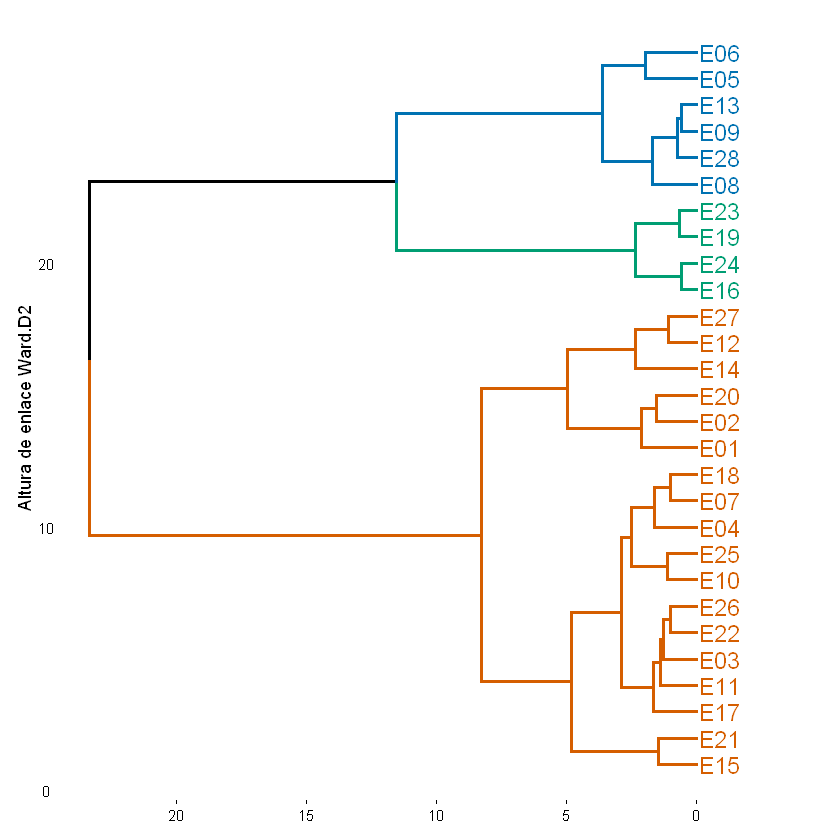

In [53]:
# ======================================================================
# CELDA 12. FIGURA 8
# DENDROGRAMA DE REGIONALIZACIÓN HIDROCLIMÁTICA
# PRESENTACIÓN EDITORIAL PARA TESIS
# ======================================================================

cat(
  "\n============================================================\n",
  "FIGURA 8. DENDROGRAMA WARD.D2\n",
  "============================================================\n"
)

# ----------------------------------------------------------------------
# 1. Número de clusters adoptado en la tesis
# ----------------------------------------------------------------------

K_CLUSTERS <- 3


# ----------------------------------------------------------------------
# 2. Crear códigos cortos para las estaciones
#
# Recomendación:
# - Usar códigos cortos en la figura principal.
# - Mantener los nombres completos en una tabla auxiliar/exportada.
# ----------------------------------------------------------------------

tabla_codigos_estaciones <- base_cluster %>%
  dplyr::arrange(estacion) %>%
  dplyr::mutate(
    codigo_estacion = paste0(
      "E",
      sprintf(
        "%02d",
        dplyr::row_number()
      )
    )
  ) %>%
  dplyr::select(
    codigo_estacion,
    estacion,
    altitud,
    latitud,
    longitud
  )

# Guardar tabla de equivalencias
readr::write_csv(
  tabla_codigos_estaciones,
  file.path(
    ruta_tablas,
    "tabla_codigos_estaciones_dendrograma.csv"
  )
)

cat("\nTabla de códigos de estaciones:\n")
print(tabla_codigos_estaciones)


# ----------------------------------------------------------------------
# 3. Asociar códigos a las hojas del dendrograma
# ----------------------------------------------------------------------

vector_codigos <- tabla_codigos_estaciones$codigo_estacion
names(vector_codigos) <- tabla_codigos_estaciones$estacion

hc_ward_cod <- hc_ward
hc_ward_cod$labels <- vector_codigos[hc_ward$labels]


# ----------------------------------------------------------------------
# 4. Colores de clusters
# ----------------------------------------------------------------------

colores_dendrograma <- c(
  "#D55E00",  # Cluster 1
  "#009E73",  # Cluster 2
  "#0072B2"   # Cluster 3
)


# ----------------------------------------------------------------------
# 5. Generar dendrograma horizontal limpio
# ----------------------------------------------------------------------

p_dendrograma <- factoextra::fviz_dend(
  hc_ward_cod,
  k = K_CLUSTERS,
  k_colors = colores_dendrograma,
  color_labels_by_k = TRUE,
  show_labels = TRUE,
  cex = 0.95,
  lwd = 0.9,
  horiz = TRUE,
  rect = FALSE,
  ggtheme = theme_classic(base_size = 11)
) +
  labs(
    title = NULL,
    x = "Altura de enlace Ward.D2",
    y = NULL
  ) +
  theme(
    legend.position = "none",
    axis.title.x = element_text(face = "bold", size = 11),
    axis.text.x = element_text(size = 9, colour = "black"),
    axis.text.y = element_text(size = 9, colour = "black"),
    axis.ticks.y = element_blank(),
    plot.margin = margin(t = 10, r = 20, b = 10, l = 10)
  )

print(p_dendrograma)


# ----------------------------------------------------------------------
# 6. Guardar figura
# ----------------------------------------------------------------------

ggsave(
  filename = file.path(ruta_figuras, "dendograma.png"),
  plot = p_dendrograma,
  width = 9.5,
  height = 7.5,
  units = "in",
  dpi = 600,
  bg = "white",
  limitsize = FALSE
)

ggsave(
  filename = file.path(ruta_figuras, "dendograma.pdf"),
  plot = p_dendrograma,
  width = 9.5,
  height = 7.5,
  units = "in",
  device = grDevices::cairo_pdf,
  bg = "white",
  limitsize = FALSE
)


# ----------------------------------------------------------------------
# 7. Guardar asignación cluster + código
# ----------------------------------------------------------------------

cluster_dendrograma <- cutree(hc_ward, k = K_CLUSTERS)

tabla_dendrograma <- tibble::tibble(
  estacion = names(
    cluster_dendrograma
  ),
  cluster_ward = as.integer(
    cluster_dendrograma
  )
) %>%
  dplyr::left_join(
    tabla_codigos_estaciones,
    by = "estacion"
  ) %>%
  dplyr::select(
    codigo_estacion,
    estacion,
    altitud,
    latitud,
    longitud,
    cluster_ward
  ) %>%
  dplyr::arrange(
    cluster_ward,
    codigo_estacion
  )

readr::write_csv(
  tabla_dendrograma,
  file.path(
    ruta_tablas,
    "fig08_dendrograma_ward.csv"
  )
)

cat(
  "\nArchivos generados:\n",
  "- Figura PNG/PDF del dendrograma\n",
  "- Tabla de equivalencias de códigos\n",
  "- Tabla de asignación cluster Ward\n",
  sep = ""
)

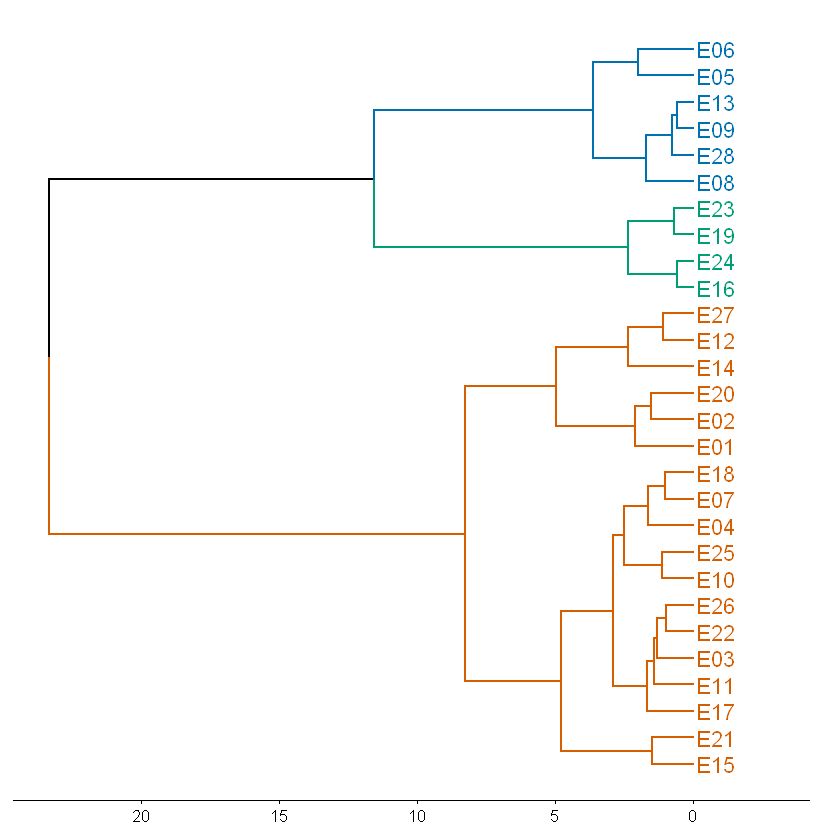

In [54]:
# ======================================================================
# DENDROGRAMA FINAL PARA TESIS
# ======================================================================

p_dendrograma <- factoextra::fviz_dend(

  hc_ward_cod,

  k = K_CLUSTERS,

  k_colors = colores_dendrograma,

  color_labels_by_k = TRUE,

  show_labels = TRUE,

  # Códigos cortos E01-E28
  cex = 0.92,

  # Ramas definidas pero no excesivamente gruesas
  lwd = 0.80,

  # Fundamental para nombres/códigos a la derecha
  horiz = TRUE,

  # Sin rectángulos: aspecto editorial más limpio
  rect = FALSE,

  ggtheme = theme_classic(
    base_size = 11
  )

) +

  labs(
    title = NULL,
    x = "Altura de enlace Ward.D2",
    y = NULL
  ) +

  theme(

    # ------------------------------------------------------------
    # El dendrograma no requiere leyenda adicional
    # ------------------------------------------------------------
    legend.position = "none",

    # ------------------------------------------------------------
    # Escala de altura de enlace
    # ------------------------------------------------------------
    axis.title.x = element_text(
      face = "bold",
      size = 11,
      margin = margin(t = 8)
    ),

    axis.text.x = element_text(
      colour = "black",
      size = 9.5
    ),

    axis.ticks.x = element_line(
      colour = "black",
      linewidth = 0.35
    ),

    # ------------------------------------------------------------
    # El eje vertical NO debe presentar escala numérica
    # ------------------------------------------------------------
    axis.title.y = element_blank(),

    axis.text.y = element_blank(),

    axis.ticks.y = element_blank(),

    axis.line.y = element_blank(),

    # ------------------------------------------------------------
    # Mantener únicamente el eje de distancia
    # ------------------------------------------------------------
    axis.line.x = element_line(
      colour = "black",
      linewidth = 0.45
    ),

    # ------------------------------------------------------------
    # Fondo completamente limpio
    # ------------------------------------------------------------
    panel.grid = element_blank(),

    panel.background = element_rect(
      fill = "white",
      colour = NA
    ),

    # ------------------------------------------------------------
    # Márgenes compactos
    # ------------------------------------------------------------
    plot.margin = margin(
      t = 8,
      r = 18,
      b = 10,
      l = 8
    )
  )


# ======================================================================
# MOSTRAR EN NOTEBOOK
# ======================================================================

print(
  p_dendrograma
)


# ======================================================================
# GUARDAR PNG
#
# Se reduce el ancho físico respecto a la versión anterior.
# Esto hace visualmente más compactas las ramas largas SIN modificar
# las distancias Ward.D2.
# ======================================================================

archivo_dendrograma_png <- file.path(
  ruta_figuras,
  "dendograma.png"
)

ggsave(
  filename = archivo_dendrograma_png,
  plot = p_dendrograma,
  width = 8.6,
  height = 8.2,
  units = "in",
  dpi = 600,
  bg = "white",
  limitsize = FALSE
)


# ======================================================================
# GUARDAR PDF VECTORIAL
# ======================================================================

archivo_dendrograma_pdf <- file.path(
  ruta_figuras,
  "dendograma.pdf"
)

ggsave(
  filename = archivo_dendrograma_pdf,
  plot = p_dendrograma,
  width = 8.6,
  height = 8.2,
  units = "in",
  device = grDevices::cairo_pdf,
  bg = "white",
  limitsize = FALSE
)


## Celda 13. Gap Statistic

El Gap Statistic se calcula de forma reproducible con semilla fija. La función interna aplica explícitamente **distancia euclidiana + Ward.D2**, de forma coherente con la metodología.

La recomendación automática se obtiene mediante la regla `firstSEmax`. El valor no se fuerza manualmente.


In [24]:
# ======================================================================
# CELDA 13. GAP STATISTIC
# EVALUACIÓN DIAGNÓSTICA DEL NÚMERO DE CLUSTERS
# ======================================================================

# ----------------------------------------------------------------------
# OBJETIVO
#
# Evaluar estadísticamente diferentes números de clusters mediante
# Gap Statistic.
#
# El procedimiento reproduce la misma configuración empleada en la
# regionalización principal:
#
#   1. matriz de 16 variables previamente estandarizadas;
#   2. distancia euclidiana;
#   3. agrupamiento jerárquico Ward.D2.
#
# IMPORTANTE:
# El Gap Statistic se utiliza como criterio DIAGNÓSTICO.
# La solución final de la tesis continúa siendo k = 3 por criterios de
# parsimonia, interpretabilidad hidroclimática y utilidad para las
# etapas probabilísticas posteriores.
#
# El resultado del Gap NO se modifica manualmente.
# ----------------------------------------------------------------------


cat(
  "\n============================================================\n",
  "GAP STATISTIC - EVALUACIÓN DEL NÚMERO DE CLUSTERS\n",
  "============================================================\n"
)


# ----------------------------------------------------------------------
# 1. Fijar semilla para garantizar reproducibilidad
# ----------------------------------------------------------------------

SEMILLA_GAP <- 123
B_GAP <- 100
K_MAX_GAP <- 10


set.seed(
  SEMILLA_GAP
)


cat(
  "Semilla reproducible       : ",
  SEMILLA_GAP,
  "\n",
  sep = ""
)

cat(
  "Réplicas bootstrap (B)     : ",
  B_GAP,
  "\n",
  sep = ""
)

cat(
  "Número máximo evaluado     : ",
  K_MAX_GAP,
  "\n",
  sep = ""
)


# ----------------------------------------------------------------------
# 2. Definir explícitamente el algoritmo utilizado dentro de clusGap()
#
# Para cada valor de k:
#
#   distancia euclidiana
#            ↓
#        Ward.D2
#            ↓
#        cutree(k)
#
# De esta forma no se depende de valores predeterminados ocultos.
# ----------------------------------------------------------------------

ward_gap_fun <- function(x, k) {

  distancia_k <- dist(
    x,
    method = "euclidean"
  )


  hc_k <- hclust(
    distancia_k,
    method = "ward.D2"
  )


  grupos_k <- cutree(
    hc_k,
    k = k
  )


  list(
    cluster = grupos_k
  )
}


# ----------------------------------------------------------------------
# 3. Calcular Gap Statistic
#
# d.power = 1 corresponde al comportamiento estándar de clusGap().
# ----------------------------------------------------------------------

gap_stat <- cluster::clusGap(
  x = mat_cluster,
  FUNcluster = ward_gap_fun,
  K.max = K_MAX_GAP,
  B = B_GAP,
  d.power = 1
)


# ----------------------------------------------------------------------
# 4. Convertir la tabla interna del Gap a tibble
#
# Se utiliza tibble para:
#   - visualizarla correctamente dentro de Jupyter;
#   - evitar errores de print.data.frame();
#   - exportarla fácilmente como CSV.
# ----------------------------------------------------------------------

gap_table <- gap_stat$Tab %>%
  as.data.frame() %>%
  tibble::as_tibble() %>%
  mutate(
    k = seq_len(
      n()
    ),
    .before = 1
  )


# ----------------------------------------------------------------------
# 5. Verificar que la tabla tenga las columnas esperadas
# ----------------------------------------------------------------------

columnas_gap_esperadas <- c(
  "k",
  "logW",
  "E.logW",
  "gap",
  "SE.sim"
)


faltantes_gap <- setdiff(
  columnas_gap_esperadas,
  names(gap_table)
)


if (length(faltantes_gap) > 0) {

  stop(
    "ERROR: faltan columnas esperadas en la tabla Gap: ",
    paste(
      faltantes_gap,
      collapse = ", "
    )
  )
}


# ----------------------------------------------------------------------
# 6. Verificar que no existan valores no finitos
# ----------------------------------------------------------------------

if (
  any(
    !is.finite(
      as.matrix(
        gap_table %>%
          select(
            -k
          )
      )
    )
  )
) {

  stop(
    "ERROR: la tabla Gap contiene NA, NaN o Inf."
  )
}


cat(
  "\nCálculo del Gap Statistic: OK\n"
)


# ----------------------------------------------------------------------
# 7. Guardar tabla completa del Gap
# ----------------------------------------------------------------------

archivo_gap <- file.path(
  ruta_tablas,
  "gap_statistic_values.csv"
)


readr::write_csv(
  gap_table,
  archivo_gap
)


# ----------------------------------------------------------------------
# 8. Determinar automáticamente el número de clusters sugerido
#
# Se emplea la regla firstSEmax:
#
# elegir el primer k cuyo Gap se encuentra dentro de un error estándar
# del primer máximo local relevante.
#
# IMPORTANTE:
# No se escribe k = 8 manualmente.
# Debe ser consecuencia de la ejecución.
# ----------------------------------------------------------------------

k_gap <- cluster::maxSE(
  gap_stat$Tab[, "gap"],
  gap_stat$Tab[, "SE.sim"],
  method = "firstSEmax"
)


# ----------------------------------------------------------------------
# 9. Mostrar la tabla completa dentro del notebook
# ----------------------------------------------------------------------

cat(
  "\nTABLA DE RESULTADOS DEL GAP STATISTIC:\n"
)


print(
  gap_table,
  n = Inf,
  width = Inf
)


# ----------------------------------------------------------------------
# 10. Mostrar la recomendación automática
# ----------------------------------------------------------------------

cat(
  "\n------------------------------------------------------------\n"
)

cat(
  "Número de clusters sugerido automáticamente por Gap: k = ",
  k_gap,
  "\n",
  sep = ""
)

cat(
  "Número de clusters adoptado en la tesis              : k = ",
  K_CLUSTERS,
  "\n",
  sep = ""
)

cat(
  "------------------------------------------------------------\n"
)


# ----------------------------------------------------------------------
# 11. Obtener la partición Ward correspondiente al k sugerido por Gap
#
# Esto permite determinar cuántas estaciones contiene cada grupo de la
# solución automática.
# ----------------------------------------------------------------------

cluster_gap <- cutree(
  hc_ward,
  k = k_gap
)


tab_gap <- table(
  cluster_gap
)


tabla_tamanos_gap <- tibble::tibble(
  cluster = as.integer(
    names(
      tab_gap
    )
  ),

  n_estaciones = as.integer(
    tab_gap
  )
)


# ----------------------------------------------------------------------
# 12. Guardar tamaños de la solución Gap
# ----------------------------------------------------------------------

archivo_tamanos_gap <- file.path(
  ruta_tablas,
  "tamanos_particion_gap.csv"
)


readr::write_csv(
  tabla_tamanos_gap,
  archivo_tamanos_gap
)


# ----------------------------------------------------------------------
# 13. Mostrar tamaños de los grupos en el notebook
# ----------------------------------------------------------------------

cat(
  "\nTAMAÑOS DE LOS GRUPOS CORRESPONDIENTES A k = ",
  k_gap,
  ":\n",
  sep = ""
)


print(
  tabla_tamanos_gap,
  n = Inf,
  width = Inf
)


# ----------------------------------------------------------------------
# 14. Verificar que la suma de los grupos sea igual al número total
#     de estaciones
# ----------------------------------------------------------------------

total_gap <- sum(
  tabla_tamanos_gap$n_estaciones
)


if (total_gap != nrow(base_cluster)) {

  stop(
    "ERROR: la suma de estaciones de la partición Gap no coincide ",
    "con el número total de estaciones."
  )
}


cat(
  "\nTotal de estaciones representadas: ",
  total_gap,
  "\n",
  sep = ""
)


# ----------------------------------------------------------------------
# 15. Registrar secuencia compacta de tamaños
#
# Esta salida facilita la comparación directa con los resultados
# documentados en la tesis.
# ----------------------------------------------------------------------

secuencia_tamanos_gap <- paste(
  tabla_tamanos_gap$n_estaciones,
  collapse = " / "
)


cat(
  "Secuencia de tamaños       : ",
  secuencia_tamanos_gap,
  "\n",
  sep = ""
)


# ----------------------------------------------------------------------
# 16. Control de coherencia con el resultado actualmente documentado
#
# La tesis documenta:
#
#   Gap automático = k = 8
#
# Este control NO modifica k_gap.
# Solamente advierte si una nueva ejecución produce un resultado distinto.
# ----------------------------------------------------------------------

if (k_gap == 8) {

  cat(
    "\nCONTROL DE COHERENCIA:\n",
    "El resultado automático del Gap coincide con la tesis: k = 8.\n",
    sep = ""
  )

} else {

  warning(
    "ATENCIÓN: el Gap Statistic produjo k = ",
    k_gap,
    " y la tesis actualmente documenta k = 8. ",
    "NO modificar manualmente el resultado. Debe revisarse la ejecución."
  )
}


# ----------------------------------------------------------------------
# 17. Control adicional de tamaños cuando k_gap = 8
#
# Resultado documentado actualmente:
#
#   3 / 9 / 2 / 4 / 3 / 2 / 4 / 1
#
# Nuevamente, solo se compara; no se fuerzan los tamaños.
# ----------------------------------------------------------------------

if (k_gap == 8) {

  tamanos_gap_tesis <- c(
    3,
    9,
    2,
    4,
    3,
    2,
    4,
    1
  )


  tamanos_gap_observados <- as.integer(
    tabla_tamanos_gap$n_estaciones
  )


  if (
    identical(
      tamanos_gap_observados,
      tamanos_gap_tesis
    )
  ) {

    cat(
      "Los tamaños de k = 8 coinciden con la tesis: ",
      paste(
        tamanos_gap_tesis,
        collapse = " / "
      ),
      "\n",
      sep = ""
    )

  } else {

    warning(
      "ATENCIÓN: k = 8 coincide, pero los tamaños observados son: ",
      paste(
        tamanos_gap_observados,
        collapse = " / "
      ),
      ". Revisar antes de actualizar la tesis."
    )
  }
}


# ----------------------------------------------------------------------
# 18. Confirmar archivos generados
# ----------------------------------------------------------------------

cat(
  "\nArchivos generados:\n"
)

cat(
  "1. ",
  archivo_gap,
  "\n",
  sep = ""
)

cat(
  "2. ",
  archivo_tamanos_gap,
  "\n",
  sep = ""
)


cat(
  "\n============================================================\n",
  "FIN DEL CÁLCULO GAP STATISTIC\n",
  "============================================================\n"
)


 GAP STATISTIC - EVALUACIÓN DEL NÚMERO DE CLUSTERS
Semilla reproducible       : 123
Réplicas bootstrap (B)     : 100
Número máximo evaluado     : 10

Cálculo del Gap Statistic: OK

TABLA DE RESULTADOS DEL GAP STATISTIC:
# A tibble: 10 × 5
       k  logW E.logW     gap SE.sim
   <int> <dbl>  <dbl>   <dbl>  <dbl>
 1     1  3.52   3.50 -0.0135 0.0531
 2     2  3.02   3.18  0.160  0.0499
 3     3  2.73   3.01  0.275  0.0472
 4     4  2.50   2.87  0.372  0.0445
 5     5  2.37   2.76  0.389  0.0439
 6     6  2.22   2.65  0.432  0.0445
 7     7  2.11   2.56  0.452  0.0459
 8     8  2.00   2.47  0.466  0.0482
 9     9  1.91   2.38  0.474  0.0479
10    10  1.80   2.29  0.495  0.0494

------------------------------------------------------------
Número de clusters sugerido automáticamente por Gap: k = 7
Número de clusters adoptado en la tesis              : k = 3
------------------------------------------------------------

TAMAÑOS DE LOS GRUPOS CORRESPONDIENTES A k = 7:
# A tibble: 7 × 2
  clus

Warning message:
"ATENCIÓN: el Gap Statistic produjo k = 7 y la tesis actualmente documenta k = 8. NO modificar manualmente el resultado. Debe revisarse la ejecución."



Archivos generados:
1. h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/gap_statistic_values.csv
2. h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/tamanos_particion_gap.csv

 FIN DEL CÁLCULO GAP STATISTIC



## Celda 14. Figura 9 — Gap Statistic y partición adoptada

- **Línea punteada:** recomendación automática del Gap Statistic.
- **Línea discontinua:** partición hidroclimática adoptada `k = 3`.

La figura se muestra en el notebook y se guarda en PNG y PDF.


Warning message in annotate("label", x = K_CLUSTERS + 0.15, y = gap_min + 0.08 * :
"Ignoring unknown parameters: `label.size`"
Warning message in annotate("label", x = k_gap - 0.15, y = gap_max, label = paste0("Criterio Gap: k = ", :
"Ignoring unknown parameters: `label.size`"


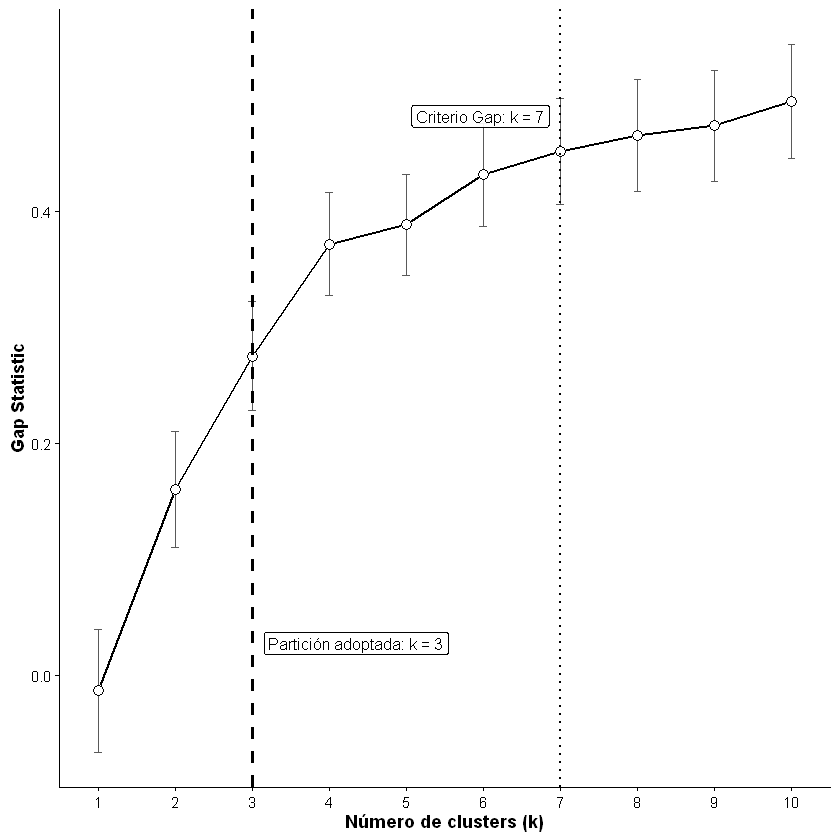

In [25]:

gap_min <- min(
  gap_table$gap,
  na.rm = TRUE
)

gap_max <- max(
  gap_table$gap,
  na.rm = TRUE
)

gap_rango <- gap_max - gap_min

if (gap_rango == 0) {
  gap_rango <- 1
}

p_gap <- ggplot(
  gap_table,
  aes(
    x = k,
    y = gap
  )
) +
  geom_errorbar(
    aes(
      ymin = gap - SE.sim,
      ymax = gap + SE.sim
    ),
    width = 0.10,
    linewidth = 0.50,
    colour = "grey35"
  ) +
  geom_line(
    linewidth = 0.75,
    colour = "black"
  ) +
  geom_point(
    size = 2.6,
    shape = 21,
    fill = "white",
    stroke = 0.8
  ) +
  geom_vline(
    xintercept = k_gap,
    linetype = "dotted",
    linewidth = 0.80
  ) +
  geom_vline(
    xintercept = K_CLUSTERS,
    linetype = "dashed",
    linewidth = 0.85
  ) +
  annotate(
    "label",
    x = K_CLUSTERS + 0.15,
    y = gap_min + 0.08 * gap_rango,
    label = paste0(
      "Partición adoptada: k = ",
      K_CLUSTERS
    ),
    hjust = 0,
    size = 3.3,
    label.size = 0,
    fill = scales::alpha(
      "white",
      0.90
    )
  ) +
  annotate(
    "label",
    x = k_gap - 0.15,
    y = gap_max,
    label = paste0(
      "Criterio Gap: k = ",
      k_gap
    ),
    hjust = 1,
    vjust = 1.15,
    size = 3.3,
    label.size = 0,
    fill = scales::alpha(
      "white",
      0.90
    )
  ) +
  scale_x_continuous(
    breaks = 1:10
  ) +
  labs(
    x = "Número de clusters (k)",
    y = "Gap Statistic"
  ) +
  theme_classic(base_size = 11) +
  theme(
    axis.title = element_text(
      face = "bold"
    ),
    axis.text = element_text(
      colour = "black"
    )
  )

print(p_gap)

ggsave(
  file.path(
    ruta_figuras,
    "gap_statistic.png"
  ),
  p_gap,
  width = 7.0,
  height = 5.2,
  dpi = 600,
  bg = "white"
)

ggsave(
  file.path(
    ruta_figuras,
    "gap_statistic.pdf"
  ),
  p_gap,
  width = 7.0,
  height = 5.2,
  device = grDevices::cairo_pdf,
  bg = "white"
)



## Celda 15. Partición final Ward.D2, `k = 3`

Esta es la clasificación oficial utilizada en las etapas posteriores de la tesis. El tamaño de cada cluster se calcula y se muestra en pantalla; no se escribe manualmente.


In [26]:

base_cluster$cluster_ward <- factor(
  cutree(
    hc_ward,
    k = K_CLUSTERS
  ),
  levels = 1:K_CLUSTERS
)

tamano_ward <- table(
  base_cluster$cluster_ward
)

cat(
  "\n============================================================\n",
  "PARTICIÓN WARD.D2 ADOPTADA\n",
  "============================================================\n"
)

print(tamano_ward)



 PARTICIÓN WARD.D2 ADOPTADA

 1  2  3 
18  6  4 



## Celda 16. Contraste independiente mediante PAM

PAM se ejecuta sobre la misma matriz estandarizada y con `k = 3`.

Antes de comparar PAM con Ward se **alinean las etiquetas nominales** de los clusters. Esto evita interpretar como desacuerdo una mera permutación de los números 1, 2 y 3.


In [28]:

set.seed(123)

pam_fit <- cluster::pam(
  mat_cluster,
  k = K_CLUSTERS,
  metric = "euclidean",
  stand = FALSE
)

cluster_pam_original <- as.integer(
  pam_fit$clustering
)

generar_permutaciones <- function(v) {
  if (length(v) == 1) {
    return(
      matrix(
        v,
        nrow = 1
      )
    )
  }

  do.call(
    rbind,
    lapply(
      seq_along(v),
      function(i) {
        resto <- generar_permutaciones(
          v[-i]
        )

        cbind(
          v[i],
          resto
        )
      }
    )
  )
}

permutaciones <- generar_permutaciones(
  1:K_CLUSTERS
)

ward_entero <- as.integer(
  as.character(
    base_cluster$cluster_ward
  )
)

evaluar_permutacion <- function(p) {
  pam_alineado <- p[
    cluster_pam_original
  ]

  sum(
    pam_alineado ==
      ward_entero
  )
}

puntajes <- apply(
  permutaciones,
  1,
  evaluar_permutacion
)

indice_mejor <- which.max(
  puntajes
)

mejor_permutacion <- permutaciones[
  indice_mejor,
]

cluster_pam_alineado <- mejor_permutacion[
  cluster_pam_original
]

base_cluster$cluster_pam <- factor(
  cluster_pam_alineado,
  levels = 1:K_CLUSTERS
)

base_cluster$coincide_ward_pam <-
  base_cluster$cluster_ward ==
  base_cluster$cluster_pam

matriz_ward_pam <- table(
  Ward = base_cluster$cluster_ward,
  PAM = base_cluster$cluster_pam
)

cat(
  "\n============================================================\n",
  "CONTRASTE WARD.D2 vs PAM\n",
  "============================================================\n"
)

print(
  matriz_ward_pam
)

n_coinciden <- sum(
  base_cluster$coincide_ward_pam
)

n_total <- nrow(
  base_cluster
)

porcentaje_concordancia <-
  100 *
  n_coinciden /
  n_total

cat(
  "\nConcordancia Ward.D2/PAM: ",
  n_coinciden,
  " de ",
  n_total,
  " estaciones (",
  round(
    porcentaje_concordancia,
    1
  ),
  "%)\n",
  sep = ""
)

discrepancias_pam <- base_cluster %>%
  filter(
    !coincide_ward_pam
  ) %>%
  select(
    estacion,
    cluster_ward,
    cluster_pam
  )

cat(
  "\nEstaciones con discrepancia Ward/PAM:\n"
)

print(
  discrepancias_pam,
  n = Inf,
  width = Inf
)



 CONTRASTE WARD.D2 vs PAM
    PAM
Ward  1  2  3
   1 17  1  0
   2  0  6  0
   3  0  0  4

Concordancia Ward.D2/PAM: 27 de 28 estaciones (96.4%)

Estaciones con discrepancia Ward/PAM:
# A tibble: 1 × 3
  estacion cluster_ward cluster_pam
  <chr>    <fct>        <fct>      
1 IMATA    1            2          



## Celda 17. Controles de coherencia con los resultados documentados en la tesis

Estos controles **no modifican ni fuerzan** los resultados. Solo generan una advertencia si una nueva ejecución deja de coincidir con los valores actualmente documentados:

- tamaños Ward: `18 / 6 / 4`;
- Gap: `k = 8`;
- concordancia Ward/PAM: `27 / 28`;
- única discrepancia: `IMATA`.


In [29]:

tam_esperados <- c(
  18,
  6,
  4
)

tam_observados <- as.integer(
  tamano_ward
)

if (
  !identical(
    tam_observados,
    tam_esperados
  )
) {
  warning(
    "ATENCIÓN: los tamaños Ward no son 18 / 6 / 4. ",
    "Revisar los resultados antes de actualizar la tesis."
  )
}

if (k_gap != 8) {
  warning(
    "ATENCIÓN: la nueva ejecución del Gap no produjo k = 8. ",
    "No modificar manualmente el resultado; revisar antes de actualizar la tesis."
  )
}

if (n_coinciden != 27) {
  warning(
    "ATENCIÓN: la concordancia Ward/PAM no fue 27/28. ",
    "Revisar la salida antes de actualizar la tesis."
  )
}

estaciones_discrepantes <- sort(
  discrepancias_pam$estacion
)

if (
  !identical(
    estaciones_discrepantes,
    "IMATA"
  )
) {
  warning(
    "ATENCIÓN: IMATA no es la única discrepancia Ward/PAM. ",
    "Revisar los nuevos resultados."
  )
}

cat("\nControles de coherencia ejecutados.\n")


Warning message:
"ATENCIÓN: los tamaños Ward no son 18 / 6 / 4. Revisar los resultados antes de actualizar la tesis."
Warning message:
"ATENCIÓN: la nueva ejecución del Gap no produjo k = 8. No modificar manualmente el resultado; revisar antes de actualizar la tesis."



Controles de coherencia ejecutados.


## Celda 18. Resumen hidroclimático de los tres clusters

In [30]:

resumen_clusters <- base_cluster %>%
  group_by(
    cluster_ward
  ) %>%
  summarise(
    n_estaciones = n(),
    altitud_media = mean(
      altitud,
      na.rm = TRUE
    ),
    ppt_anual_media = mean(
      ppt_anual,
      na.rm = TRUE
    ),
    frac_djfm_media = mean(
      frac_djfm,
      na.rm = TRUE
    ),
    cv_mensual_media = mean(
      cv_mensual,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

readr::write_csv(
  resumen_clusters,
  file.path(
    ruta_tablas,
    "resumen_clusters_ward.csv"
  )
)

resumen_clusters_mostrar <- resumen_clusters %>%
  mutate(
    altitud_media = round(
      altitud_media,
      1
    ),
    ppt_anual_media = round(
      ppt_anual_media,
      2
    ),
    frac_djfm_media = round(
      frac_djfm_media,
      4
    ),
    cv_mensual_media = round(
      cv_mensual_media,
      4
    )
  )

cat(
  "\n============================================================\n",
  "RESUMEN HIDROCLIMÁTICO POR CLUSTER\n",
  "============================================================\n"
)

print(
  resumen_clusters_mostrar,
  n = Inf,
  width = Inf
)



 RESUMEN HIDROCLIMÁTICO POR CLUSTER
# A tibble: 3 × 6
  cluster_ward n_estaciones altitud_media ppt_anual_media frac_djfm_media cv_mensual_media
  <fct>               <int>         <dbl>           <dbl>           <dbl>            <dbl>
1 1                      18        3635            747.             0.725            0.937
2 2                       6        2961.           258.             0.882            1.37 
3 3                       4          48.2            5.51           0.366            0.683



## Celda 19. Tablas 7, 8 y 9

Las tres tablas se muestran en el cuaderno y se exportan como CSV:

- **Tabla 7:** asignación oficial Ward.D2;
- **Tabla 8:** comparación Ward–PAM;
- **Tabla 9:** indicadores hidroclimáticos y cluster.


In [31]:

# ------------------------------------------------------------
# TABLA 7
# ------------------------------------------------------------

tabla_07_ward <- base_cluster %>%
  select(
    estacion,
    cluster_ward
  ) %>%
  arrange(
    cluster_ward,
    estacion
  )

readr::write_csv(
  tabla_07_ward,
  file.path(
    ruta_tablas,
    "tabla_07_asignacion_ward.csv"
  )
)

tabla_07_ward_resumen <- tabla_07_ward %>%
  group_by(
    cluster_ward
  ) %>%
  summarise(
    estaciones = paste(
      estacion,
      collapse = ", "
    ),
    .groups = "drop"
  )

readr::write_csv(
  tabla_07_ward_resumen,
  file.path(
    ruta_tablas,
    "tabla_07_asignacion_ward_resumen.csv"
  )
)

cat("\nTABLA 7. ASIGNACIÓN WARD.D2\n")
print(
  tabla_07_ward_resumen,
  n = Inf,
  width = Inf
)

# ------------------------------------------------------------
# TABLA 8
# ------------------------------------------------------------

tabla_08_ward_pam <- base_cluster %>%
  select(
    estacion,
    cluster_ward,
    cluster_pam,
    coincide_ward_pam
  ) %>%
  arrange(estacion)

readr::write_csv(
  tabla_08_ward_pam,
  file.path(
    ruta_tablas,
    "comparacion_ward_pam.csv"
  )
)

readr::write_csv(
  tabla_08_ward_pam,
  file.path(
    ruta_tablas,
    "tabla_08_comparacion_ward_pam.csv"
  )
)

cat("\nTABLA 8. CONTRASTE WARD.D2 / PAM\n")
print(
  tabla_08_ward_pam,
  n = Inf,
  width = Inf
)

# ------------------------------------------------------------
# TABLA 9
# ------------------------------------------------------------

tabla_09_indicadores <- base_cluster %>%
  select(
    estacion,
    latitud,
    longitud,
    altitud,
    cluster_ward,
    ppt_anual,
    frac_djfm,
    cv_mensual,
    frac_mjjas,
    mes_pico
  ) %>%
  arrange(
    cluster_ward,
    estacion
  )

readr::write_csv(
  tabla_09_indicadores,
  file.path(
    ruta_tablas,
    "tabla_09_indicadores_clusters.csv"
  )
)

cat("\nTABLA 9. INDICADORES HIDROCLIMÁTICOS POR ESTACIÓN\n")
print(
  tabla_09_indicadores,
  n = Inf,
  width = Inf
)



TABLA 7. ASIGNACIÓN WARD.D2
# A tibble: 3 × 2
  cluster_ward
  <fct>       
1 1           
2 2           
3 3           
  estaciones                                                                                                                                                    
  <chr>                                                                                                                                                         
1 ANANEA, ANDAHUAYLAS, ANTA ANCACHURO, AYMARAES, CAYLLOMA, CURPAHUASI, GRANJA KAYRA, GRANJA SAN ANTONIO, HUARAYA MOHO, IMATA, MACUSANI, MAÑAZO, PAUCARAY, PIZAC…
2 CANDARAVE, CARAVELI, CORA CORA, COTAHUASI, HUAMBO, UBINAS                                                                                                     
3 LA YARADA, PAMPA BLANCA, PUNTA ATICO, PUNTA COLES                                                                                                             

TABLA 8. CONTRASTE WARD.D2 / PAM
# A tibble: 28 × 4
   estacion         


## Celda 20. Exportación de la base final de regionalización

Esta salida sustituye el uso de archivos históricos con sufijos como `_ORIGINAL`. Se conserva una copia intermedia para las etapas posteriores y una copia en resultados para trazabilidad.


In [32]:

readr::write_csv(
  base_cluster,
  file.path(
    ruta_intermedios,
    "base_cluster_estaciones.csv"
  )
)

readr::write_csv(
  base_cluster,
  file.path(
    ruta_procesados,
    "estaciones_clusters.csv"
  )
)

readr::write_csv(
  base_cluster,
  file.path(
    ruta_tablas,
    "estaciones_clusters.csv"
  )
)

cat(
  "\nBase final exportada:\n",
  file.path(
    ruta_intermedios,
    "base_cluster_estaciones.csv"
  ),
  "\n"
)



Base final exportada:
 h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/01_datos/intermedios/base_cluster_estaciones.csv 



## Celda 21. Figura 10 — distribución espacial de los clusters hidroclimáticos

El mapa es únicamente representativo. **No participa en el algoritmo de clustering**. Los tamaños de los clusters se obtienen dinámicamente de la ejecución.


In [35]:
# ============================================================
# INSTALAR PAQUETES CARTOGRÁFICOS FALTANTES EN EL ENTORNO RENV
# ============================================================

renv::install(
  c(
    "rnaturalearth",
    "rnaturalearthdata"
  )
)

- Querying repositories for available source packages ... Done!
The following package(s) will be installed:
- rnaturalearth     [1.2.0]
- rnaturalearthdata [1.0.0]
These packages will be installed into "C:/Users/DELL/AppData/Local/R/win-library/4.5".

# Downloading packages -------------------------------------------------------
✔ rnaturalearth 1.2.0                      [2.1 MB in 6.9s]                                                                                            
✔ rnaturalearthdata 1.0.0                  [3.3 MB in 8.9s]                                                                                            
Successfully downloaded 2 packages in 58 seconds.                                                                                                               

# Installing packages --------------------------------------------------------
✔ rnaturalearth 1.2.0                      [installed binary in 7.1s]                                                       

In [36]:
packageVersion("rnaturalearth")
packageVersion("rnaturalearthdata")

[1] '1.2.0'

[1] '1.0.0'


 FIGURA 10. DISTRIBUCIÓN ESPACIAL DE LOS CLUSTERS
Paquetes cartográficos: OK
Geometría nacional del Perú: OK
Estaciones convertidas a objeto espacial: 28

Tamaños de los clusters representados:

 1  2  3 
18  6  4 

DATOS QUE SUSTENTAN LA FIGURA 10:
# A tibble: 28 × 7
   estacion           longitud latitud altitud cluster_ward cluster_pam coincide_ward_pam
   <chr>                 <dbl>   <dbl>   <dbl> <fct>        <fct>       <lgl>            
 1 ANANEA                -69.5   -14.7    4660 1            1           TRUE             
 2 ANDAHUAYLAS           -73.4   -13.6    2865 1            1           TRUE             
 3 ANTA ANCACHURO        -72.2   -13.5    3324 1            1           TRUE             
 4 AYMARAES              -73.3   -14.3    2964 1            1           TRUE             
 5 CAYLLOMA              -71.8   -15.2    4327 1            1           TRUE             
 6 CURPAHUASI            -72.7   -14.1    3535 1            1           TRUE             
 7 GRANJA 

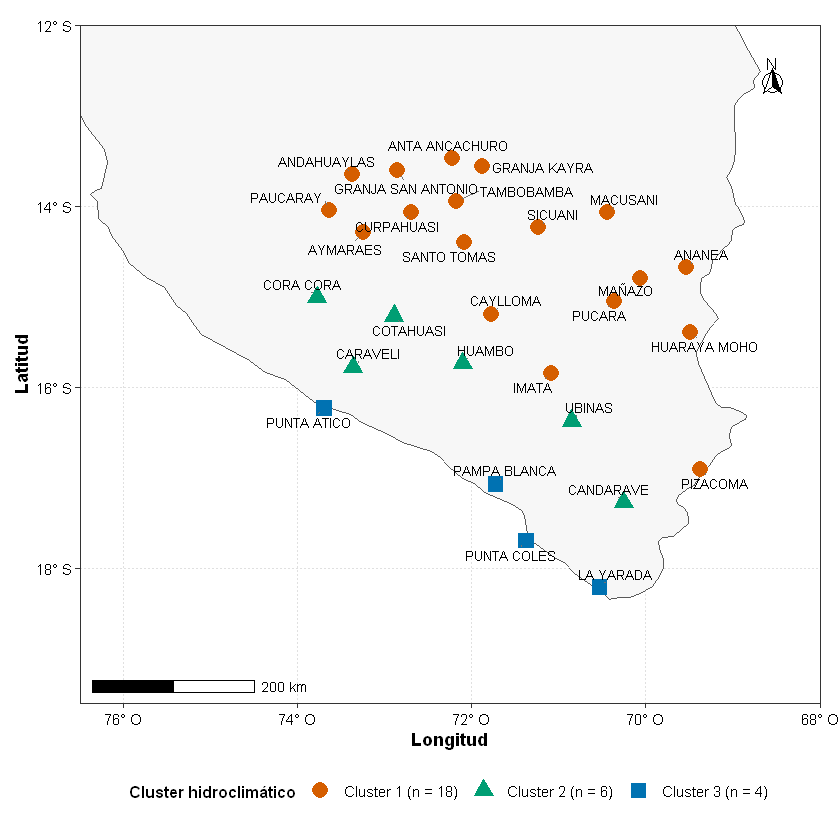

In [37]:
# ======================================================================
# CELDA 21. FIGURA 10
# DISTRIBUCIÓN ESPACIAL DE LOS CLUSTERS HIDROCLIMÁTICOS
# ======================================================================

# ----------------------------------------------------------------------
# OBJETIVO
#
# Representar espacialmente las 28 estaciones meteorológicas y su
# clasificación hidroclimática obtenida mediante Ward.D2 (k = 3).
#
# IMPORTANTE:
#
# Este mapa es únicamente una representación cartográfica de los
# resultados del clustering.
#
# La posición geográfica NO interviene en el algoritmo Ward.D2.
# Los clusters fueron obtenidos previamente a partir de las 16 variables
# hidroclimáticas estandarizadas.
# ----------------------------------------------------------------------


cat(
  "\n============================================================\n",
  "FIGURA 10. DISTRIBUCIÓN ESPACIAL DE LOS CLUSTERS\n",
  "============================================================\n"
)


# ======================================================================
# 1. VERIFICAR PAQUETES CARTOGRÁFICOS
# ======================================================================

paquetes_mapa <- c(
  "sf",
  "rnaturalearth",
  "rnaturalearthdata",
  "ggspatial"
)


paquetes_faltantes <- paquetes_mapa[
  !vapply(
    paquetes_mapa,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]


if (length(paquetes_faltantes) > 0) {

  stop(
    paste0(
      "ERROR: faltan paquetes necesarios para la cartografía avanzada: ",
      paste(
        paquetes_faltantes,
        collapse = ", "
      ),
      "\n\nInstálelos una sola vez con:\n\n",
      "install.packages(c(",
      paste0(
        '"',
        paquetes_faltantes,
        '"',
        collapse = ", "
      ),
      "))"
    )
  )
}


cat(
  "Paquetes cartográficos: OK\n"
)


# ======================================================================
# 2. OBTENER EL LÍMITE NACIONAL DEL PERÚ
# ======================================================================

# ----------------------------------------------------------------------
# Natural Earth proporciona una geometría vectorial reproducible del
# territorio nacional.
#
# No se descarga un mapa manual ni se utiliza una imagen de fondo.
# ----------------------------------------------------------------------

peru_sf <- rnaturalearth::ne_countries(
  scale = "medium",
  country = "Peru",
  returnclass = "sf"
)


if (nrow(peru_sf) == 0) {

  stop(
    "ERROR: no fue posible obtener la geometría del Perú."
  )
}


# Sistema geográfico WGS84
peru_sf <- sf::st_transform(
  peru_sf,
  crs = 4326
)


cat(
  "Geometría nacional del Perú: OK\n"
)


# ======================================================================
# 3. CONVERTIR LAS ESTACIONES A OBJETO ESPACIAL SF
# ======================================================================

estaciones_sf <- sf::st_as_sf(
  base_cluster,
  coords = c(
    "longitud",
    "latitud"
  ),
  crs = 4326,
  remove = FALSE
)


cat(
  "Estaciones convertidas a objeto espacial: ",
  nrow(estaciones_sf),
  "\n",
  sep = ""
)


# ======================================================================
# 4. TAMAÑOS DINÁMICOS DE LOS CLUSTERS
# ======================================================================

# ----------------------------------------------------------------------
# No se escriben manualmente 18, 6 y 4.
# Los tamaños proceden directamente de la ejecución actual.
# ----------------------------------------------------------------------

tam_cluster <- table(
  base_cluster$cluster_ward
)


cat(
  "\nTamaños de los clusters representados:\n"
)

print(
  tam_cluster
)


labels_cluster <- paste0(
  "Cluster ",
  1:K_CLUSTERS,
  " (n = ",
  as.integer(
    tam_cluster[
      as.character(
        1:K_CLUSTERS
      )
    ]
  ),
  ")"
)


# ======================================================================
# 5. ETIQUETAS DE CLUSTER
# ======================================================================

base_cluster <- base_cluster %>%
  mutate(

    cluster_label = factor(

      paste0(
        "Cluster ",
        cluster_ward,
        " (n = ",
        as.integer(
          tam_cluster[
            as.character(
              cluster_ward
            )
          ]
        ),
        ")"
      ),

      levels = labels_cluster
    )
  )


# Reconstruir sf para incorporar cluster_label
estaciones_sf <- sf::st_as_sf(
  base_cluster,
  coords = c(
    "longitud",
    "latitud"
  ),
  crs = 4326,
  remove = FALSE
)


# ======================================================================
# 6. SIMBOLOGÍA
# ======================================================================

# ----------------------------------------------------------------------
# Se emplean simultáneamente:
#
#   - color;
#   - forma geométrica.
#
# Así el mapa sigue siendo interpretable incluso si se imprime en
# escala de grises.
# ----------------------------------------------------------------------

colores_cluster <- c(
  "#D55E00",
  "#009E73",
  "#0072B2"
)


names(
  colores_cluster
) <- labels_cluster


formas_cluster <- c(
  16,   # círculo
  17,   # triángulo
  15    # cuadrado
)


names(
  formas_cluster
) <- labels_cluster


# ======================================================================
# 7. EXTRAER COORDENADAS PARA ETIQUETAS
# ======================================================================

# ----------------------------------------------------------------------
# geom_text_repel() trabaja con columnas x/y convencionales.
# Se extraen por ello las coordenadas del objeto sf.
# ----------------------------------------------------------------------

coord_estaciones <- sf::st_coordinates(
  estaciones_sf
)


etiquetas_estaciones <- estaciones_sf %>%
  sf::st_drop_geometry() %>%
  mutate(
    x = coord_estaciones[, 1],
    y = coord_estaciones[, 2]
  )


# ======================================================================
# 8. EXTENSIÓN CARTOGRÁFICA
# ======================================================================

# ----------------------------------------------------------------------
# Límites seleccionados para mostrar la región sur del Perú donde se
# distribuyen las estaciones, evitando un exceso de espacio vacío.
# ----------------------------------------------------------------------

xmin <- -76.5
xmax <- -68.0
ymin <- -19.5
ymax <- -12.0


# ======================================================================
# 9. CONSTRUIR MAPA DE PUBLICACIÓN
# ======================================================================

p_mapa <- ggplot() +

  # ------------------------------------------------------------
  # Territorio peruano
  # ------------------------------------------------------------

  geom_sf(
    data = peru_sf,
    fill = "grey97",
    colour = "grey35",
    linewidth = 0.55
  ) +

  # ------------------------------------------------------------
  # Estaciones meteorológicas
  # ------------------------------------------------------------

  geom_sf(
    data = estaciones_sf,
    aes(
      colour = cluster_label,
      shape = cluster_label
    ),
    size = 3.7,
    stroke = 1.0
  ) +

  # ------------------------------------------------------------
  # Etiquetas de estaciones
  # ------------------------------------------------------------

  ggrepel::geom_text_repel(
    data = etiquetas_estaciones,
    aes(
      x = x,
      y = y,
      label = estacion
    ),
    size = 2.65,
    colour = "black",
    min.segment.length = 0,
    segment.size = 0.25,
    segment.colour = "grey45",
    box.padding = 0.25,
    point.padding = 0.20,
    max.overlaps = Inf,
    seed = 123,
    show.legend = FALSE
  ) +

  # ------------------------------------------------------------
  # Paleta y símbolos
  # ------------------------------------------------------------

  scale_colour_manual(
    values = colores_cluster,
    drop = FALSE
  ) +

  scale_shape_manual(
    values = formas_cluster,
    drop = FALSE
  ) +

  # ------------------------------------------------------------
  # Escala gráfica
  # ------------------------------------------------------------

  ggspatial::annotation_scale(
    location = "bl",
    width_hint = 0.22,
    text_cex = 0.70,
    line_width = 0.6
  ) +

  # ------------------------------------------------------------
  # Flecha norte
  # ------------------------------------------------------------

  ggspatial::annotation_north_arrow(
    location = "tr",
    which_north = "true",
    pad_x = grid::unit(
      0.25,
      "in"
    ),
    pad_y = grid::unit(
      0.30,
      "in"
    ),
    height = grid::unit(
      0.75,
      "cm"
    ),
    width = grid::unit(
      0.75,
      "cm"
    ),
    style =
      ggspatial::north_arrow_fancy_orienteering
  ) +

  # ------------------------------------------------------------
  # Ventana geográfica
  # ------------------------------------------------------------

  coord_sf(
    xlim = c(
      xmin,
      xmax
    ),
    ylim = c(
      ymin,
      ymax
    ),
    expand = FALSE,
    datum = sf::st_crs(4326)
  ) +

  # ------------------------------------------------------------
  # Ejes geográficos
  # ------------------------------------------------------------

  scale_x_continuous(
    breaks = seq(
      -76,
      -68,
      by = 2
    ),
    labels = function(x) {
      paste0(
        abs(x),
        "° O"
      )
    }
  ) +

  scale_y_continuous(
    breaks = seq(
      -18,
      -12,
      by = 2
    ),
    labels = function(x) {
      paste0(
        abs(x),
        "° S"
      )
    }
  ) +

  # ------------------------------------------------------------
  # Títulos y leyenda
  # ------------------------------------------------------------

  labs(
    x = "Longitud",
    y = "Latitud",
    colour = "Cluster hidroclimático",
    shape = "Cluster hidroclimático"
  ) +

  # ------------------------------------------------------------
  # Diseño editorial
  # ------------------------------------------------------------

  theme_bw(
    base_size = 11
  ) +

  theme(

    panel.background =
      element_rect(
        fill = "white",
        colour = NA
      ),

    panel.grid.major =
      element_line(
        colour = "grey88",
        linewidth = 0.30,
        linetype = "dotted"
      ),

    panel.grid.minor =
      element_blank(),

    axis.title =
      element_text(
        face = "bold",
        size = 10.5
      ),

    axis.text =
      element_text(
        colour = "black",
        size = 9
      ),

    legend.position =
      "bottom",

    legend.direction =
      "horizontal",

    legend.title =
      element_text(
        face = "bold",
        size = 9.5
      ),

    legend.text =
      element_text(
        size = 9
      ),

    legend.box =
      "horizontal",

    plot.margin =
      margin(
        8,
        12,
        8,
        8
      )
  )


# ======================================================================
# 10. MOSTRAR FIGURA EN EL NOTEBOOK
# ======================================================================

print(
  p_mapa
)


# ======================================================================
# 11. GUARDAR FIGURA EN PNG
# ======================================================================

archivo_mapa_png <- file.path(
  ruta_figuras,
  "mapa_clusters_estaciones.png"
)


ggsave(
  filename = archivo_mapa_png,
  plot = p_mapa,
  width = 8.8,
  height = 8.5,
  dpi = 600,
  bg = "white"
)


# ======================================================================
# 12. GUARDAR FIGURA VECTORIAL EN PDF
# ======================================================================

archivo_mapa_pdf <- file.path(
  ruta_figuras,
  "mapa_clusters_estaciones.pdf"
)


ggsave(
  filename = archivo_mapa_pdf,
  plot = p_mapa,
  width = 8.8,
  height = 8.5,
  device = grDevices::cairo_pdf,
  bg = "white"
)


# ======================================================================
# 13. GUARDAR DATOS CARTOGRÁFICOS
# ======================================================================

# ----------------------------------------------------------------------
# Se guarda la información utilizada para reconstruir el mapa:
#
# estación
# longitud
# latitud
# altitud
# cluster Ward
# cluster PAM
# concordancia Ward/PAM
# ----------------------------------------------------------------------

tabla_mapa <- base_cluster %>%
  select(
    estacion,
    longitud,
    latitud,
    altitud,
    cluster_ward,
    cluster_pam,
    coincide_ward_pam
  ) %>%
  arrange(
    cluster_ward,
    estacion
  )


archivo_datos_mapa <- file.path(
  ruta_tablas,
  "fig10_mapa_clusters_estaciones.csv"
)


readr::write_csv(
  tabla_mapa,
  archivo_datos_mapa
)


# ======================================================================
# 14. MOSTRAR TABLA CARTOGRÁFICA EN EL NOTEBOOK
# ======================================================================

cat(
  "\nDATOS QUE SUSTENTAN LA FIGURA 10:\n"
)


print(
  tibble::as_tibble(
    tabla_mapa
  ),
  n = Inf,
  width = Inf
)


# ======================================================================
# 15. CONFIRMACIÓN FINAL
# ======================================================================

cat(
  "\n============================================================\n",
  "FIGURA 10 GENERADA CORRECTAMENTE\n",
  "============================================================\n"
)


cat(
  "Estaciones representadas : ",
  nrow(
    tabla_mapa
  ),
  "\n",
  sep = ""
)


cat(
  "Sistema de coordenadas    : WGS84 (EPSG:4326)\n"
)


cat(
  "Clasificación mostrada    : Ward.D2, k = ",
  K_CLUSTERS,
  "\n",
  sep = ""
)


cat(
  "\nArchivos generados:\n"
)


cat(
  "PNG  : ",
  archivo_mapa_png,
  "\n",
  sep = ""
)


cat(
  "PDF  : ",
  archivo_mapa_pdf,
  "\n",
  sep = ""
)


cat(
  "CSV  : ",
  archivo_datos_mapa,
  "\n",
  sep = ""
)


cat(
  "============================================================\n"
)


## Celda 22. Figura 11 — visualización multivariada mediante PCA

El PCA se usa **solo como representación gráfica** de la estructura multivariada. No se utiliza para construir los clusters. Ward.D2 continúa operando directamente sobre las 16 variables estandarizadas.



 FIGURA 11. VISUALIZACIÓN MULTIVARIADA MEDIANTE PCA

Varianza explicada por PC1 : 75.2%
Varianza explicada por PC2 : 15.6%
Varianza acumulada PC1+PC2 : 90.8%

Estaciones representadas en PCA: 28

CENTROIDES EN EL ESPACIO PCA:
# A tibble: 3 × 4
  cluster_label        PC1    PC2     n
  <fct>              <dbl>  <dbl> <int>
1 Cluster 1 (n = 18) -2.32 -0.109    18
2 Cluster 2 (n = 6)   3.21  2.04      6
3 Cluster 3 (n = 4)   5.63 -2.57      4


Warning message:
"Duplicated `override.aes` is ignored."
Warning message:
"Duplicated `override.aes` is ignored."
Warning message:
"Duplicated `override.aes` is ignored."



 FIGURA 11 GENERADA CORRECTAMENTE
PC1                       : 75.2%
PC2                       : 15.6%
PC1 + PC2                 : 90.8%
Estaciones representadas  : 28

Archivos generados:
PNG : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/figuras/visualizacion_clusters.png
PDF : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/figuras/visualizacion_clusters.pdf
CSV : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/fig11_pca_clusters.csv
CSV centroides : h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/fig11_centroides_pca.csv


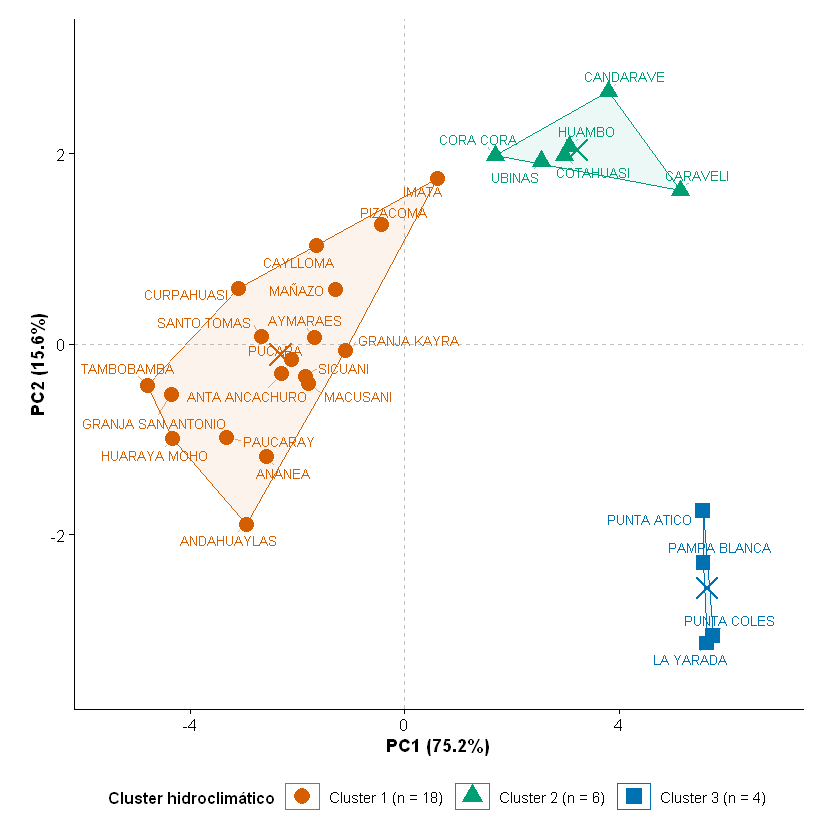

In [44]:
# ======================================================================
# CELDA 22. FIGURA 11
# VISUALIZACIÓN MULTIVARIADA DE LOS CLUSTERS MEDIANTE PCA
# ======================================================================

# ----------------------------------------------------------------------
# OBJETIVO
#
# Representar gráficamente la estructura multivariada de las estaciones
# meteorológicas en el espacio definido por los dos primeros componentes
# principales.
#
# IMPORTANTE:
#
# El PCA se utiliza EXCLUSIVAMENTE como herramienta de visualización.
# NO participa en la construcción de los clusters.
#
# La regionalización oficial fue obtenida previamente mediante:
#
#   16 variables estandarizadas
#           ↓
#   distancia euclidiana
#           ↓
#        Ward.D2
#           ↓
#          k = 3
# ----------------------------------------------------------------------


cat(
  "\n============================================================\n",
  "FIGURA 11. VISUALIZACIÓN MULTIVARIADA MEDIANTE PCA\n",
  "============================================================\n"
)


# ======================================================================
# 1. CALCULAR PCA
# ======================================================================

# mat_cluster ya está:
#   - centrada;
#   - escalada;
#   - compuesta por las 16 variables de regionalización.
#
# Por ello no se vuelve a centrar ni escalar.

pca_fit <- prcomp(
  mat_cluster,
  center = FALSE,
  scale. = FALSE
)


# ======================================================================
# 2. VARIANZA EXPLICADA
# ======================================================================

varianza_pca <- summary(
  pca_fit
)$importance[
  2,
  1:2
] * 100


varianza_pc1 <- varianza_pca[1]
varianza_pc2 <- varianza_pca[2]

varianza_acumulada <- sum(
  varianza_pca
)


cat(
  "\nVarianza explicada por PC1 : ",
  round(varianza_pc1, 1),
  "%\n",
  sep = ""
)

cat(
  "Varianza explicada por PC2 : ",
  round(varianza_pc2, 1),
  "%\n",
  sep = ""
)

cat(
  "Varianza acumulada PC1+PC2 : ",
  round(varianza_acumulada, 1),
  "%\n",
  sep = ""
)


# ======================================================================
# 3. EXTRAER PUNTAJES PCA
# ======================================================================

pca_scores <- as.data.frame(
  pca_fit$x[
    ,
    1:2,
    drop = FALSE
  ]
) %>%
  tibble::rownames_to_column(
    var = "estacion"
  ) %>%
  tibble::as_tibble() %>%
  left_join(
    base_cluster %>%
      select(
        estacion,
        cluster_ward,
        cluster_label
      ),
    by = "estacion"
  )


# ======================================================================
# 4. VERIFICAR INTEGRIDAD
# ======================================================================

if (nrow(pca_scores) != nrow(base_cluster)) {

  stop(
    "ERROR: el número de estaciones del PCA no coincide con base_cluster."
  )
}


if (anyNA(pca_scores$cluster_ward)) {

  stop(
    "ERROR: existen estaciones PCA sin clasificación Ward."
  )
}


cat(
  "\nEstaciones representadas en PCA: ",
  nrow(pca_scores),
  "\n",
  sep = ""
)


# ======================================================================
# 5. POLÍGONOS CONVEXOS DE LOS CLUSTERS
# ======================================================================

# ----------------------------------------------------------------------
# Los polígonos son únicamente ayudas visuales.
#
# NO representan límites geográficos ni regiones probabilísticas.
# ----------------------------------------------------------------------

hulls <- pca_scores %>%
  group_by(
    cluster_label
  ) %>%
  slice(
    chull(
      PC1,
      PC2
    )
  ) %>%
  ungroup()


# ======================================================================
# 6. CENTROIDES DE LOS CLUSTERS EN EL ESPACIO PCA
# ======================================================================

centroides_pca <- pca_scores %>%
  group_by(
    cluster_label
  ) %>%
  summarise(
    PC1 = mean(
      PC1,
      na.rm = TRUE
    ),
    PC2 = mean(
      PC2,
      na.rm = TRUE
    ),
    n = n(),
    .groups = "drop"
  )


cat(
  "\nCENTROIDES EN EL ESPACIO PCA:\n"
)

print(
  centroides_pca,
  n = Inf,
  width = Inf
)


# ======================================================================
# 7. SIMBOLOGÍA
# ======================================================================

# Se mantienen colores y formas diferenciadas para facilitar la lectura.
# Las formas permiten interpretar la figura incluso en impresión
# monocromática.

colores_cluster <- c(
  "#D55E00",
  "#009E73",
  "#0072B2"
)


names(
  colores_cluster
) <- levels(
  pca_scores$cluster_label
)


formas_cluster <- c(
  16,
  17,
  15
)


names(
  formas_cluster
) <- levels(
  pca_scores$cluster_label
)


# ======================================================================
# 8. CONSTRUIR FIGURA
# ======================================================================

set.seed(
  123
)


p_pca <- ggplot(
  pca_scores,
  aes(
    x = PC1,
    y = PC2
  )
) +

  # ------------------------------------------------------------
  # Líneas de referencia en el origen
  # ------------------------------------------------------------

  geom_hline(
    yintercept = 0,
    linewidth = 0.35,
    linetype = "dashed",
    colour = "grey75"
  ) +

  geom_vline(
    xintercept = 0,
    linewidth = 0.35,
    linetype = "dashed",
    colour = "grey75"
  ) +

  # ------------------------------------------------------------
  # Envolventes convexas
  # ------------------------------------------------------------

  geom_polygon(
    data = hulls,
    aes(
      x = PC1,
      y = PC2,
      group = cluster_label,
      fill = cluster_label
    ),
    alpha = 0.075,
    colour = NA,
    inherit.aes = FALSE
  ) +

  # ------------------------------------------------------------
  # Borde de las envolventes
  # ------------------------------------------------------------

  geom_polygon(
    data = hulls,
    aes(
      x = PC1,
      y = PC2,
      group = cluster_label,
      colour = cluster_label
    ),
    fill = NA,
    linewidth = 0.45,
    alpha = 0.35,
    inherit.aes = FALSE
  ) +

  # ------------------------------------------------------------
  # Estaciones
  # ------------------------------------------------------------

  geom_point(
    aes(
      colour = cluster_label,
      shape = cluster_label
    ),
    size = 3.6,
    stroke = 0.85
  ) +

  # ------------------------------------------------------------
  # Centroides
  #
  # El símbolo 4 corresponde a una cruz.
  # Se utiliza únicamente como referencia visual del centro promedio
  # de cada cluster en el plano PCA.
  # ------------------------------------------------------------

  geom_point(
    data = centroides_pca,
    aes(
      x = PC1,
      y = PC2,
      colour = cluster_label
    ),
    shape = 4,
    size = 5.2,
    stroke = 1.15,
    inherit.aes = FALSE,
    show.legend = FALSE
  ) +

  # ------------------------------------------------------------
  # Etiquetas de estaciones
  # ------------------------------------------------------------

  ggrepel::geom_text_repel(
    aes(
      label = estacion,
      colour = cluster_label
    ),

    size = 2.75,

    box.padding = 0.35,

    point.padding = 0.30,

    min.segment.length = 0,

    segment.size = 0.25,

    segment.alpha = 0.55,

    max.overlaps = Inf,

    force = 1.25,

    force_pull = 0.40,

    max.time = 5,

    seed = 123,

    show.legend = FALSE
  ) +

  # ------------------------------------------------------------
  # Simbología
  # ------------------------------------------------------------

  scale_colour_manual(
    values = colores_cluster,
    drop = FALSE
  ) +

  scale_fill_manual(
    values = colores_cluster,
    drop = FALSE
  ) +

  scale_shape_manual(
    values = formas_cluster,
    drop = FALSE
  ) +

  # ------------------------------------------------------------
  # Dar espacio adicional a las etiquetas
  # ------------------------------------------------------------

  scale_x_continuous(
    expand = expansion(
      mult = c(
        0.13,
        0.16
      )
    )
  ) +

  scale_y_continuous(
    expand = expansion(
      mult = c(
        0.12,
        0.13
      )
    )
  ) +

  # ------------------------------------------------------------
  # Ejes PCA
  # ------------------------------------------------------------

  labs(

    x = paste0(
      "PC1 (",
      round(
        varianza_pc1,
        1
      ),
      "%)"
    ),

    y = paste0(
      "PC2 (",
      round(
        varianza_pc2,
        1
      ),
      "%)"
    ),

    colour = "Cluster hidroclimático",

    fill = "Cluster hidroclimático",

    shape = "Cluster hidroclimático"
  ) +

  # ------------------------------------------------------------
  # Diseño editorial
  # ------------------------------------------------------------

  theme_classic(
    base_size = 11
  ) +

  theme(

    axis.line =
      element_line(
        colour = "black",
        linewidth = 0.5
      ),

    axis.title =
      element_text(
        face = "bold",
        size = 11
      ),

    axis.text =
      element_text(
        colour = "black",
        size = 9.5
      ),

    legend.position =
      "bottom",

    legend.direction =
      "horizontal",

    legend.title =
      element_text(
        face = "bold",
        size = 9.5
      ),

    legend.text =
      element_text(
        size = 9
      ),

    legend.key.width =
      grid::unit(
        0.75,
        "cm"
      ),

    legend.spacing.x =
      grid::unit(
        0.15,
        "cm"
      ),

    plot.margin =
      margin(
        12,
        22,
        12,
        18
      )
  ) +

  guides(

    fill = "none",

    colour = guide_legend(
      override.aes = list(
        size = 4
      )
    ),

    shape = guide_legend(
      override.aes = list(
        size = 4
      )
    )
  ) +

  coord_cartesian(
    clip = "off"
  )


# ======================================================================
# 9. MOSTRAR FIGURA EN EL NOTEBOOK
# ======================================================================

print(
  p_pca
)


# ======================================================================
# 10. GUARDAR FIGURA EN PNG
# ======================================================================

archivo_pca_png <- file.path(
  ruta_figuras,
  "visualizacion_clusters.png"
)


ggsave(
  filename = archivo_pca_png,
  plot = p_pca,
  width = 9.0,
  height = 7.4,
  dpi = 600,
  bg = "white"
)


# ======================================================================
# 11. GUARDAR FIGURA VECTORIAL EN PDF
# ======================================================================

archivo_pca_pdf <- file.path(
  ruta_figuras,
  "visualizacion_clusters.pdf"
)


ggsave(
  filename = archivo_pca_pdf,
  plot = p_pca,
  width = 9.0,
  height = 7.4,
  device = grDevices::cairo_pdf,
  bg = "white"
)


# ======================================================================
# 12. GUARDAR DATOS QUE SUSTENTAN LA FIGURA
# ======================================================================

archivo_pca_csv <- file.path(
  ruta_tablas,
  "fig11_pca_clusters.csv"
)


readr::write_csv(
  pca_scores,
  archivo_pca_csv
)


archivo_centroides_csv <- file.path(
  ruta_tablas,
  "fig11_centroides_pca.csv"
)


readr::write_csv(
  centroides_pca,
  archivo_centroides_csv
)


# ======================================================================
# 13. RESULTADO FINAL
# ======================================================================

cat(
  "\n============================================================\n",
  "FIGURA 11 GENERADA CORRECTAMENTE\n",
  "============================================================\n"
)


cat(
  "PC1                       : ",
  round(
    varianza_pc1,
    1
  ),
  "%\n",
  sep = ""
)


cat(
  "PC2                       : ",
  round(
    varianza_pc2,
    1
  ),
  "%\n",
  sep = ""
)


cat(
  "PC1 + PC2                 : ",
  round(
    varianza_acumulada,
    1
  ),
  "%\n",
  sep = ""
)


cat(
  "Estaciones representadas  : ",
  nrow(
    pca_scores
  ),
  "\n",
  sep = ""
)


cat(
  "\nArchivos generados:\n"
)


cat(
  "PNG : ",
  archivo_pca_png,
  "\n",
  sep = ""
)


cat(
  "PDF : ",
  archivo_pca_pdf,
  "\n",
  sep = ""
)


cat(
  "CSV : ",
  archivo_pca_csv,
  "\n",
  sep = ""
)


cat(
  "CSV centroides : ",
  archivo_centroides_csv,
  "\n",
  sep = ""
)


cat(
  "============================================================\n"
)

## Celda 23. Datos que sustentan las Figuras 8–11

In [39]:

pca_export <- pca_scores %>%
  select(
    estacion,
    PC1,
    PC2
  )

fig08_11_regionalizacion <- base_cluster %>%
  left_join(
    matriz_estandarizada,
    by = "estacion"
  ) %>%
  left_join(
    pca_export,
    by = "estacion"
  )

readr::write_csv(
  fig08_11_regionalizacion,
  file.path(
    ruta_tablas,
    "fig08_11_regionalizacion.csv"
  )
)

cat("\nDatos de respaldo de las Figuras 8–11:\n")
print(
  fig08_11_regionalizacion,
  n = Inf,
  width = Inf
)



Datos de respaldo de las Figuras 8–11:
# A tibble: 28 × 45
   estacion           latitud longitud altitud    p_01    p_02     p_03    p_04   p_05   p_06   p_07   p_08   p_09   p_10   p_11     p_12 ppt_anual ppt_djfm
   <chr>                <dbl>    <dbl>   <dbl>   <dbl>   <dbl>    <dbl>   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>    <dbl>     <dbl>    <dbl>
 1 ANANEA               -14.7    -69.5    4660 123.    103.     94.7    45.0    14.9    9.29   8.96  13.5   23.6   43.5   58.3    92.4       631.    413.   
 2 ANDAHUAYLAS          -13.6    -73.4    2865 122.    120.    102.     40.2    17.6   10.6   11.3   16.6   28.4   42.6   52.3    84.5       649.    429.   
 3 ANTA ANCACHURO       -13.5    -72.2    3324 160.    142.    120.     45.4     9.29   5.80   5.50   7.81  18.5   52.6   90.1   125.        782.    547.   
 4 AYMARAES             -14.3    -73.3    2964 160.    152.    121.     41.1    10.1    6.35   6.11  10.2   19.0   39.0   42.1    93.8       701.    527.  

## Celda 24. Diagnóstico global de regionalización

In [40]:

diagnostico_regionalizacion <- tibble(
  indicador = c(
    "archivo_entrada",
    "md5_base",
    "n_registros",
    "n_estaciones",
    "fecha_inicio",
    "fecha_fin",
    "n_variables_cluster",
    "distancia",
    "metodo_clustering",
    "semilla_gap",
    "bootstrap_gap",
    "k_gap",
    "k_adoptado",
    "tamano_cluster_1",
    "tamano_cluster_2",
    "tamano_cluster_3",
    "coincidencias_ward_pam",
    "total_ward_pam",
    "porcentaje_concordancia",
    "estaciones_discrepantes",
    "altitud_pucara"
  ),
  valor = c(
    basename(ruta_input),
    md5_base,
    as.character(n_registros),
    as.character(n_estaciones),
    as.character(fecha_inicio),
    as.character(fecha_fin),
    "16",
    "Euclidiana",
    "Ward.D2",
    "123",
    "100",
    as.character(k_gap),
    as.character(K_CLUSTERS),
    as.character(tamano_ward[1]),
    as.character(tamano_ward[2]),
    as.character(tamano_ward[3]),
    as.character(n_coinciden),
    as.character(n_total),
    as.character(
      round(
        porcentaje_concordancia,
        4
      )
    ),
    ifelse(
      length(
        estaciones_discrepantes
      ) == 0,
      "NINGUNA",
      paste(
        estaciones_discrepantes,
        collapse = "; "
      )
    ),
    as.character(
      altitud_pucara
    )
  )
)

readr::write_csv(
  diagnostico_regionalizacion,
  file.path(
    ruta_tablas,
    "diagnostico_regionalizacion.csv"
  )
)

cat(
  "\n============================================================\n",
  "DIAGNÓSTICO GLOBAL DE REGIONALIZACIÓN\n",
  "============================================================\n"
)

print(
  diagnostico_regionalizacion,
  n = Inf,
  width = Inf
)



 DIAGNÓSTICO GLOBAL DE REGIONALIZACIÓN
# A tibble: 21 × 2
   indicador               valor                           
   <chr>                   <chr>                           
 1 archivo_entrada         Base_Datos_Final_ETo_Pivot.csv  
 2 md5_base                7235b7dc7b685f99cfb62ede8d744cf5
 3 n_registros             18144                           
 4 n_estaciones            28                              
 5 fecha_inicio            1970-01-01                      
 6 fecha_fin               2023-12-01                      
 7 n_variables_cluster     16                              
 8 distancia               Euclidiana                      
 9 metodo_clustering       Ward.D2                         
10 semilla_gap             123                             
11 bootstrap_gap           100                             
12 k_gap                   7                               
13 k_adoptado              3                               
14 tamano_cluster_1        18            


## Celda 25. Guardar objetos estadísticos para auditoría

Estos objetos `.rds` no sustituyen la reproducción desde cero; se guardan como evidencia adicional de la ejecución congelada.


In [45]:

saveRDS(
  hc_ward,
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_hc_ward.rds"
  )
)

saveRDS(
  gap_stat,
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_gap_stat.rds"
  )
)

saveRDS(
  pam_fit,
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_pam_fit.rds"
  )
)

saveRDS(
  pca_fit,
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_pca_visualizacion.rds"
  )
)

cat("\nObjetos RDS de auditoría guardados correctamente.\n")



Objetos RDS de auditoría guardados correctamente.


## Celda 26. Información del entorno de R

In [46]:

session_txt <- capture.output(
  sessionInfo()
)

writeLines(
  session_txt,
  con = file.path(
    ruta_reproducibilidad,
    "sessionInfo_regionalizacion.txt"
  )
)

cat("\nINFORMACIÓN DEL ENTORNO R:\n")
print(
  sessionInfo()
)



INFORMACIÓN DEL ENTORNO R:
R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 10 x64 (build 19045)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=Spanish_Peru.utf8  LC_CTYPE=Spanish_Peru.utf8    LC_MONETARY=Spanish_Peru.utf8 LC_NUMERIC=C                  LC_TIME=Spanish_Peru.utf8    

time zone: America/Lima
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] scales_1.4.0     ggrepel_0.9.8    maps_3.4.3       factoextra_2.2.0 cluster_2.1.8.3  janitor_2.2.1    lubridate_1.9.5  forcats_1.0.1    stringr_1.6.0   
[10] dplyr_1.2.0      purrr_1.2.1      readr_2.2.0      tidyr_1.3.2      tibble_3.3.1     ggplot2_4.0.2    tidyverse_2.0.0  here_1.0.2      

loaded via a namespace (and not attached):
 [1] gtable_0.3.6            rstatix_1.1.0           tzdb_0.5.0              vctrs_0.7.1             tools_4.5.2             generi


## Celda 27. Manifiesto de productos generados

El manifiesto verifica automáticamente la existencia y tamaño de los archivos principales producidos por este notebook.


In [47]:

archivos_esperados <- c(
  file.path(
    ruta_tablas,
    "resumen_estaciones_base.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_06_resumen_global_base.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_07_asignacion_ward.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_07_asignacion_ward_resumen.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_08_comparacion_ward_pam.csv"
  ),
  file.path(
    ruta_tablas,
    "tabla_09_indicadores_clusters.csv"
  ),
  file.path(
    ruta_tablas,
    "comparacion_ward_pam.csv"
  ),
  file.path(
    ruta_tablas,
    "resumen_clusters_ward.csv"
  ),
  file.path(
    ruta_tablas,
    "gap_statistic_values.csv"
  ),
  file.path(
    ruta_tablas,
    "tamanos_particion_gap.csv"
  ),
  file.path(
    ruta_tablas,
    "diagnostico_particiones_ward_k2_k10.csv"
  ),
  file.path(
    ruta_tablas,
    "matriz_16_variables_estandarizadas.csv"
  ),
  file.path(
    ruta_tablas,
    "matriz_distancias_euclidianas.csv"
  ),
  file.path(
    ruta_tablas,
    "fig07_climatologia.csv"
  ),
  file.path(
    ruta_tablas,
    "fig08_11_regionalizacion.csv"
  ),
  file.path(
    ruta_tablas,
    "diagnostico_regionalizacion.csv"
  ),
  file.path(
    ruta_tablas,
    "estaciones_clusters.csv"
  ),

  file.path(
    ruta_figuras,
    "climatologia_mensual_estaciones.png"
  ),
  file.path(
    ruta_figuras,
    "climatologia_mensual_estaciones.pdf"
  ),
  file.path(
    ruta_figuras,
    "dendograma.png"
  ),
  file.path(
    ruta_figuras,
    "dendograma.pdf"
  ),
  file.path(
    ruta_figuras,
    "gap_statistic.png"
  ),
  file.path(
    ruta_figuras,
    "gap_statistic.pdf"
  ),
  file.path(
    ruta_figuras,
    "mapa_clusters_estaciones.png"
  ),
  file.path(
    ruta_figuras,
    "mapa_clusters_estaciones.pdf"
  ),
  file.path(
    ruta_figuras,
    "visualizacion_clusters.png"
  ),
  file.path(
    ruta_figuras,
    "visualizacion_clusters.pdf"
  ),

  file.path(
    ruta_intermedios,
    "base_cluster_estaciones.csv"
  ),
  file.path(
    ruta_procesados,
    "estaciones_clusters.csv"
  ),

  file.path(
    ruta_reproducibilidad,
    "regionalizacion_hc_ward.rds"
  ),
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_gap_stat.rds"
  ),
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_pam_fit.rds"
  ),
  file.path(
    ruta_reproducibilidad,
    "regionalizacion_pca_visualizacion.rds"
  ),
  file.path(
    ruta_reproducibilidad,
    "sessionInfo_regionalizacion.txt"
  )
)

tipo_archivo <- case_when(
  stringr::str_detect(
    archivos_esperados,
    "\\.(png|pdf)$"
  ) ~ "figura",
  stringr::str_detect(
    archivos_esperados,
    "\\.rds$|sessionInfo"
  ) ~ "reproducibilidad",
  stringr::str_detect(
    archivos_esperados,
    "01_datos"
  ) ~ "datos",
  TRUE ~ "tabla"
)

archivos_generados <- tibble(
  tipo = tipo_archivo,
  archivo = archivos_esperados
) %>%
  mutate(
    existe = file.exists(
      archivo
    ),
    tamano_bytes = ifelse(
      existe,
      file.info(archivo)$size,
      NA_real_
    )
  )

readr::write_csv(
  archivos_generados,
  file.path(
    ruta_reproducibilidad,
    "manifiesto_regionalizacion.csv"
  )
)

cat(
  "\n============================================================\n",
  "MANIFIESTO DE ARCHIVOS GENERADOS\n",
  "============================================================\n"
)

print(
  archivos_generados,
  n = Inf,
  width = Inf
)

if (any(!archivos_generados$existe)) {
  warning(
    "ATENCIÓN: uno o más productos esperados no fueron generados. ",
    "Revise el manifiesto antes de dar por cerrada la ejecución."
  )
}



 MANIFIESTO DE ARCHIVOS GENERADOS
# A tibble: 34 × 4
   tipo             archivo                                                                                                                 existe tamano_bytes
   <chr>            <chr>                                                                                                                   <lgl>         <dbl>
 1 tabla            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/resumen_estaciones_base.csv             TRUE           2675
 2 tabla            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/tabla_06_resumen_global_base.csv        TRUE           1002
 3 tabla            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/tabla_07_asignacion_ward.csv            TRUE            365
 4 tabla            h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas/tabla_07_asignacion_ward_resumen.csv    TRUE  


## Celda 28. Resumen final para  auditoría

Esta celda concentra los resultados metodológicos que deben compararse con la versión final de la tesis. Si alguno cambia, **no debe forzarse en el código**; debe revisarse antes de actualizar el documento.


In [48]:

cat(
  "\n\n",
  "============================================================\n",
  " REGIONALIZACIÓN HIDROCLIMÁTICA - EJECUCIÓN FINAL\n",
  "============================================================\n",
  sep = ""
)

cat(
  "Base analizada             : ",
  basename(ruta_input),
  "\n",
  sep = ""
)

cat(
  "MD5 de la base             : ",
  md5_base,
  "\n",
  sep = ""
)

cat(
  "Registros                  : ",
  n_registros,
  "\n",
  sep = ""
)

cat(
  "Estaciones                 : ",
  n_estaciones,
  "\n",
  sep = ""
)

cat(
  "Variables del clustering   : 16\n"
)

cat(
  "Estandarización            : scale()\n"
)

cat(
  "Distancia                  : euclidiana\n"
)

cat(
  "Método jerárquico          : Ward.D2\n"
)

cat(
  "Gap Statistic              : k = ",
  k_gap,
  "\n",
  sep = ""
)

cat(
  "Partición adoptada         : k = ",
  K_CLUSTERS,
  "\n",
  sep = ""
)

cat(
  "Tamaños Ward               : ",
  paste(
    as.integer(tamano_ward),
    collapse = " / "
  ),
  "\n",
  sep = ""
)

cat(
  "Concordancia Ward/PAM      : ",
  n_coinciden,
  "/",
  n_total,
  " = ",
  round(
    porcentaje_concordancia,
    1
  ),
  "%\n",
  sep = ""
)

cat(
  "Discrepancia(s) Ward/PAM   : ",
  ifelse(
    length(estaciones_discrepantes) == 0,
    "NINGUNA",
    paste(
      estaciones_discrepantes,
      collapse = ", "
    )
  ),
  "\n",
  sep = ""
)

cat(
  "Altitud PUCARA utilizada   : ",
  altitud_pucara,
  " m s.n.m.\n",
  sep = ""
)

cat(
  "\nLas tablas y figuras se guardaron en:\n"
)

cat(
  "  TABLAS  -> ",
  ruta_tablas,
  "\n",
  sep = ""
)

cat(
  "  FIGURAS -> ",
  ruta_figuras,
  "\n",
  sep = ""
)

cat(
  "\nLa clasificación oficial para las etapas posteriores es:\n",
  "Ward.D2, k = 3.\n",
  sep = ""
)

cat(
  "PAM se utilizó exclusivamente como contraste independiente.\n"
)

cat(
  "El Gap Statistic se utilizó como criterio diagnóstico y su resultado\n",
  "no fue modificado para hacer coincidir la partición final.\n",
  sep = ""
)

cat(
  "============================================================\n"
)




 REGIONALIZACIÓN HIDROCLIMÁTICA - EJECUCIÓN FINAL
Base analizada             : Base_Datos_Final_ETo_Pivot.csv
MD5 de la base             : 7235b7dc7b685f99cfb62ede8d744cf5
Registros                  : 18144
Estaciones                 : 28
Variables del clustering   : 16
Estandarización            : scale()
Distancia                  : euclidiana
Método jerárquico          : Ward.D2
Gap Statistic              : k = 7
Partición adoptada         : k = 3
Tamaños Ward               : 18 / 6 / 4
Concordancia Ward/PAM      : 27/28 = 96.4%
Discrepancia(s) Ward/PAM   : IMATA
Altitud PUCARA utilizada   : 3877 m s.n.m.

Las tablas y figuras se guardaron en:
  TABLAS  -> h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/tablas
  FIGURAS -> h:/Tesis_UNCP/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/01_regionalizacion/figuras

La clasificación oficial para las etapas posteriores es:
Ward.D2, k = 3.
PAM se utilizó exclusivamente como contraste independiente.
El Gap Statistic se ut